# Retrieval-Augmented Generation (RAG): Motivation and Foundations

## Why Plain LLMs Are Not Enough

Large Language Models (LLMs) rely entirely on the data they were trained on.
This introduces a **knowledge cutoff problem**.

Example:
- Model trained until **September 2024**
- User asks about an event from **October 2024**
- Model cannot answer correctly (or hallucinates)

### Why Not Just Retrain the Model?

Retraining or continual fine-tuning to inject new knowledge is **not ideal**:

1. **Risk of regression**
   - Updating knowledge can degrade previously learned capabilities

2. **Operational complexity**
   - Every fine-tuned variant would need re-updating
   - Maintenance overhead becomes impractical

3. **Cost**
   - Large-scale retraining is expensive and slow

---

## Naive Solution: Put Everything in the Prompt ❌

### Idea
Add all new information directly into the prompt.

### Problems

#### 1. Context Length Limitations
- Even with large context windows (e.g., **400k tokens**)
- Still insufficient for large knowledge bases

> Approximation:  
> 1 token ≈ 4 characters  
> 400k tokens ≈ hundreds of pages

#### 2. Performance Degradation (Needle-in-a-Haystack Problem)

- Adding large amounts of irrelevant text **hurts model performance**
- LLMs struggle to retrieve the correct fact when:
  - Prompt is very long
  - Relevant information appears early or deep inside the prompt

**Needle-in-a-Haystack Test**
- Hide a single fact inside a large document
- Ask the model to retrieve it
- Performance drops as:
  - Prompt length increases
  - Fact position shifts away from the end

#### 3. Cost Explosion 💸
- LLM pricing is **per token**
- Large prompts → higher inference cost
- Incentive to keep prompts small and relevant

---

## Key Insight 💡

We need a method that:
- Avoids retraining the model
- Avoids stuffing everything into the prompt
- Injects **only relevant information**

---

# Retrieval-Augmented Generation (RAG)

## Definition

**RAG = Retrieve → Augment → Generate**

Instead of asking the LLM to answer directly:
1. Retrieve relevant external information
2. Augment the prompt with this information
3. Generate the final answer

---

## High-Level RAG Pipeline

1. **Retrieve**
   - Find relevant documents or text chunks from a knowledge base
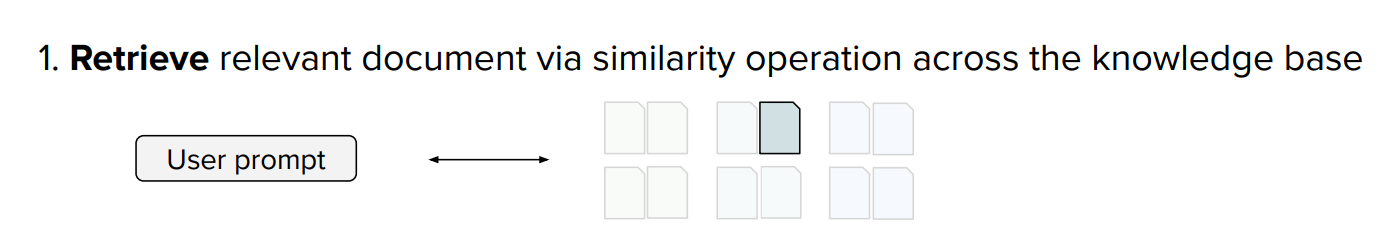

2. **Augment**
   - Insert retrieved information into the prompt
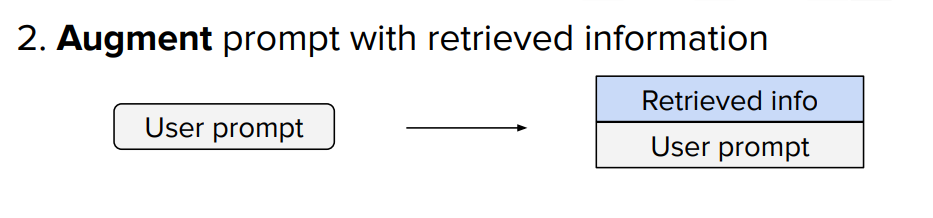

3. **Generate**
   - Ask the LLM to produce the answer using the augmented prompt
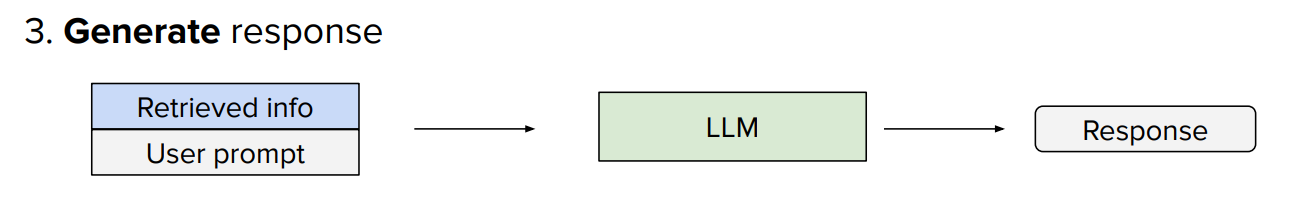

---

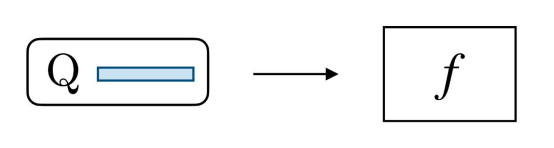

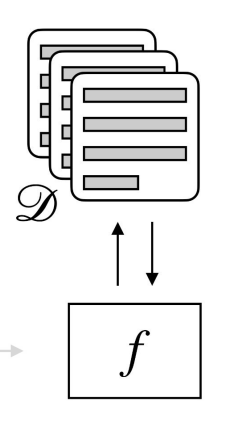

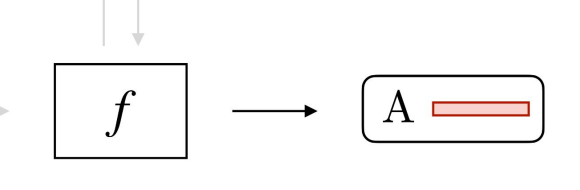


---

## Example

User query:
> Who won the recent local election?

RAG process:
1. Retrieve election result documents
2. Add them to the prompt:


**`Context:`**
**`The local election held on <date> was won by <candidate>.`**

**`Question:`**
**`Who won the recent local election?`**

3. LLM generates a correct answer

---

## Why Retrieval Quality Matters

- If retrieval is wrong → generation is wrong
- RAG performance is **dominated by retrieval quality**
- Most RAG improvements focus on **better retrieval**

---

# Building the Knowledge Base

## Step 1: Collect Documents

Sources may include:
- PDFs
- Web pages
- Internal docs
- Databases
- Logs

This collection is called the **knowledge base**.

---

## Step 2: Chunking

Documents are split into smaller units called **chunks**.

### Why Chunking?

- Retrieval works on chunks, not full documents
- Chunks balance:
- Context completeness
- Embedding quality

### Chunk Size
- Typically **hundreds of tokens**
- Common range: **300–600 tokens**

Trade-off:
- Too small → loses context
- Too large → embeddings become less precise

---

## Step 3: Chunk Overlap

Chunks often overlap to preserve continuity.

Example:
- Chunk size: 500 tokens
- Overlap: 100 tokens

Benefits:
- Avoids splitting important context
- Improves retrieval accuracy

---

## Step 4: Embeddings

Each chunk is converted into a **vector embedding**.

### Embedding Model Options
1. Pretrained embedding models (most common)
2. Custom-trained embeddings (advanced use cases)

### Embedding Size
- Typically **~1,000–2,000 dimensions**
- Trade-off:
- Larger → more expressive
- Smaller → faster and cheaper

---

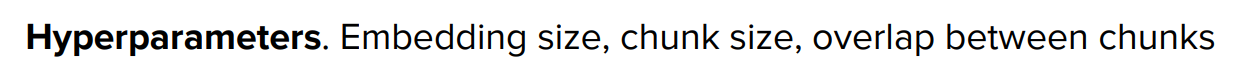


---

# Retrieving Relevant Information

## Two-Stage Retrieval Strategy

### Stage 1: Candidate Retrieval (High Recall)

Goal:
- Reduce millions of chunks → few hundred candidates
- Prioritize **recall over precision**

Method:
- Vector similarity search (cosine similarity / dot product)

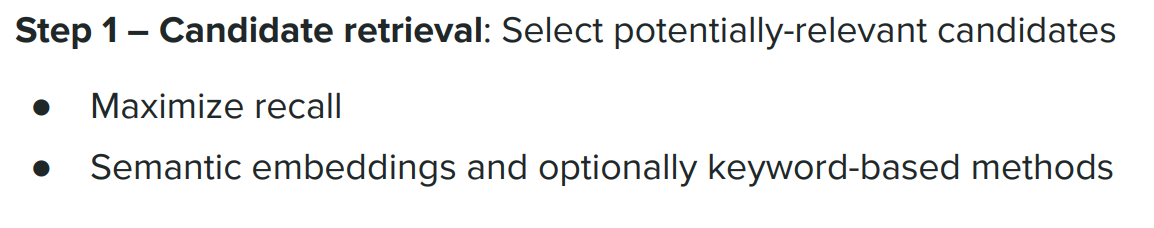

---

### Stage 2: Ranking (High Precision)

Goal:
- Rank retrieved candidates accurately
- Ensure top results are truly relevant

Characteristics:
- Smaller candidate set
- More compute-intensive models allowed
- Often uses cross-encoders or rerankers

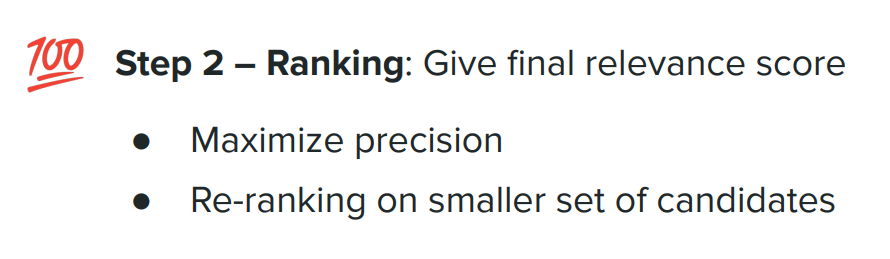

---

## Analogy (Search Systems)

- Stage 1 = Broad search
- Stage 2 = Fine ranking

Borrowed from:
- Information retrieval
- Recommendation systems
- Search engines

---

## Important Notes on Chunking Strategy

- Naive token-based chunking can break structure
- Document structure matters:
- Markdown
- JSON
- Code
- Tables

Advanced chunking strategies:
- Structure-aware chunking
- Semantic chunking
- Hierarchical chunking (covered later)

---


# RAG Retrieval Stage I: Candidate Retrieval (Semantic Search)

Now that we are clear on the **two-stage retrieval pipeline**, we focus on each step in detail.

This section covers **Candidate Retrieval**, whose goal is to:
- Reduce a **large knowledge base** (potentially millions of chunks)
- Down to a **small set of likely relevant candidates** (e.g., top 50–200)

---

## Goal of Candidate Retrieval

- **High recall**
- Fast filtering
- Accept some false positives
- Ensure we do **not miss relevant documents**

This stage is intentionally **coarse**.

---

## Core Idea: Semantic Similarity Search

Candidate retrieval is performed using **semantic similarity**, not keyword matching.

### Key Components
- Query embedding
- Chunk embeddings (precomputed)
- Similarity metric (usually cosine similarity)

---

## Embedding-Based Retrieval Pipeline

1. **Encode the query**
   - Pass user query through an embedding model
   - Obtain a query vector

2. **Compare with chunk embeddings**
   - Each chunk already has a stored embedding
   - Compute similarity between:
     - Query embedding
     - Chunk embedding

3. **Rank by similarity score**
   - Higher similarity → more relevant
   - Keep top *k* candidates (e.g., 100)

---

## Similarity Metric

### Cosine Similarity (Most Common)

Given two embeddings $( \mathbf{q} $) and $( \mathbf{d} $):

$$
\text{cosine\_similarity}(\mathbf{q}, \mathbf{d}) =
\frac{\mathbf{q} \cdot \mathbf{d}}{\|\mathbf{q}\| \|\mathbf{d}\|}
$$

Properties:
- Measures **angle**, not magnitude
- Robust to scale
- Works well when embeddings are normalized

---

### Alternative Metrics

You may also encounter:
- **L2 distance**
- **Dot product**

Observation:
- If embeddings are normalized to unit length:
  - L2 distance and cosine similarity are closely related

In practice:
- Most systems use **cosine similarity**

---

## Why Semantic Similarity?

Semantic retrieval:
- Does **not rely on keyword overlap**
- Matches based on **meaning**

Example:
- Query: *"How to reset a forgotten password?"*
- Retrieved chunk may not contain:
  - “reset”
  - “forgotten”
- But still discusses account recovery

This is fundamentally different from classical keyword search.

---

## Scaling Problem: Large Knowledge Bases

A naive approach:
- Compare query embedding against **all chunk embeddings**
- Complexity: $( O(N) $)

This does **not scale** when:
- Knowledge base has millions of chunks

---

## Approximate Nearest Neighbor (ANN) Search

To solve the scalability issue, systems use **Approximate Nearest Neighbor (ANN)** algorithms.

### Key Idea
- Trade **exactness** for **speed**
- Retrieve *approximately* nearest vectors
- Huge speed-up with minimal quality loss

---

### Common ANN Libraries
- FAISS
- HNSW
- ScaNN
- Annoy

What they do:
- Partition embedding space
- Build indexes
- Avoid full linear scans

This step happens during **knowledge base construction**.

---

## Encoder Architecture: Bi-Encoder

Candidate retrieval typically uses a **Bi-Encoder** architecture.

### What is a Bi-Encoder?

- Query and document are encoded **independently**
- Two forward passes:
  - One for the query
  - One for the chunk

Similarity is computed **after encoding**.

Diagrammatically:

**`Query ──▶ Encoder ──▶ Query Embedding`**

**`Chunk ──▶ Encoder ──▶ Chunk Embedding`**


Then:
Similarity(Query Embedding, Chunk Embedding)


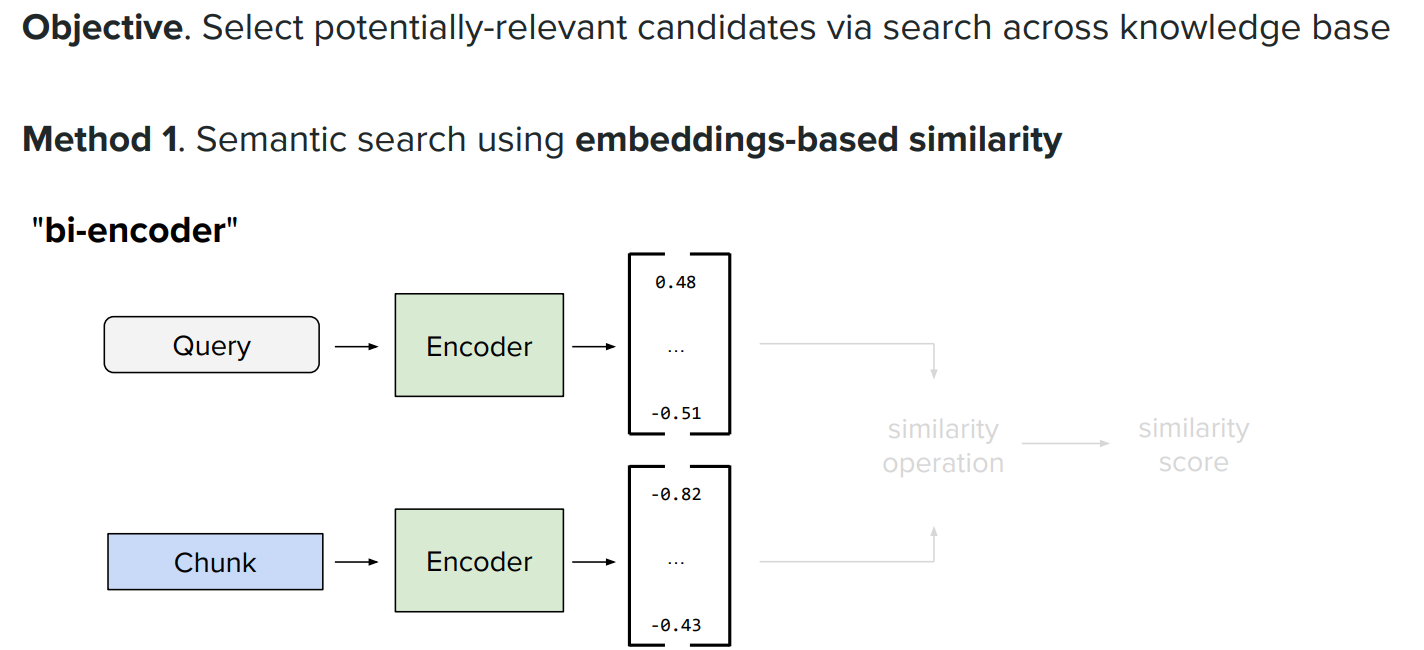
---

## Why Bi-Encoders Are Used Here

Advantages:
- Embeddings can be **precomputed**
- Fast retrieval
- Scales well

Disadvantages:
- Less expressive than joint models
- Accepts some false positives (handled later in ranking)

---

## Sentence-BERT (SBERT)

A widely used approach for embedding-based retrieval.

### What is Sentence-BERT?

- Extension of BERT
- Produces **fixed-size embeddings** for sentences/documents
- Designed specifically for similarity search

---

### Training Objective

SBERT is trained to:
- Maximize cosine similarity for **relevant pairs**
- Minimize cosine similarity for **irrelevant pairs**

Typical loss functions:
- Contrastive loss
- Triplet loss
- Cosine similarity loss

---

### Why SBERT Works Well for RAG

- Produces high-quality semantic embeddings
- Efficient at inference
- Strong baseline for retrieval

Recommended reading:
> *Sentence-BERT: Sentence Embeddings using Siamese BERT-Networks*

---

## Important Clarification: Semantic vs Keyword Search

Keyword Search:
- Requires exact word matches
- Brittle
- Fails on paraphrases

Semantic Search:
- Matches **meaning**
- Robust to wording changes
- Ideal for natural language queries

RAG retrieval is **semantic**, not lexical.

---

## Summary: Candidate Retrieval

- Uses **embedding-based semantic search**
- Relies on **bi-encoder architecture**
- Optimized for:
  - High recall
  - Speed
  - Scalability
- Powered by:
  - Cosine similarity
  - Approximate nearest neighbor search
- Outputs a **small candidate set** for ranking

---



# RAG Retrieval: Keyword Search, BM25, and Hybrid Retrieval

Sometimes, semantic similarity **alone is not sufficient**.

There are cases where you want to ensure that:
- Retrieved documents **explicitly contain keywords**
- Exact term overlap matters more than semantic similarity

This is where **lexical (keyword-based) retrieval** becomes important.

---

## Keyword-Based Retrieval with BM25

### What is BM25?

- BM25 is a **heuristic relevance scoring function**
- Widely used in classical information retrieval
- Based on **term overlap** between:
  - Query
  - Document

BM25 scores documents higher when:
- Query terms appear frequently in the document
- Terms are rare across the corpus (IDF effect)
- Document length is reasonable (length normalization)

---

## Intuition Behind BM25

BM25 answers the question:

> *How well does this document match the query based on exact words?*

Unlike embeddings:
- BM25 **guarantees keyword presence**
- Embedding similarity does **not**

---

## Motivating Example: Cuddly vs Huggy

### Scenario

- Two teddy bears:
  - One named **Cuddly**
  - One named **Huggy**

### Query

Where is Cuddly?


---

### Using BM25

- Retrieved documents **must contain the word “Cuddly”**
- Guarantees keyword overlap
- Correct when exact entity matching is required



---

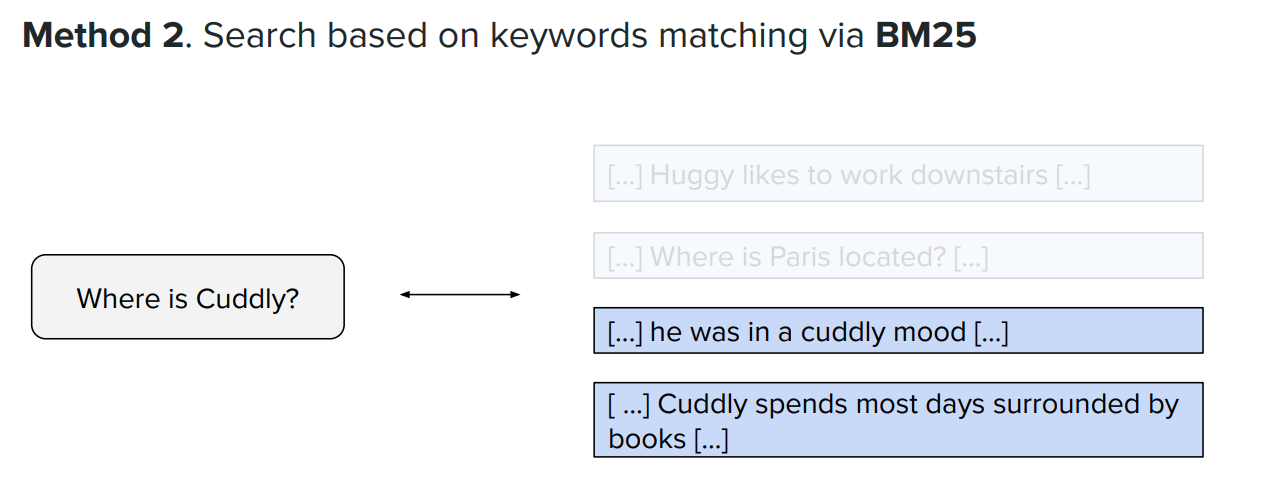

---

### Using Semantic Search Only

- Embedding similarity may retrieve:
  - Documents about **Huggy**
- Because:
  - Huggy and Cuddly are semantically similar
- But:
  - “Cuddly” may **not appear at all**

This can be **undesirable** when exact identifiers matter.


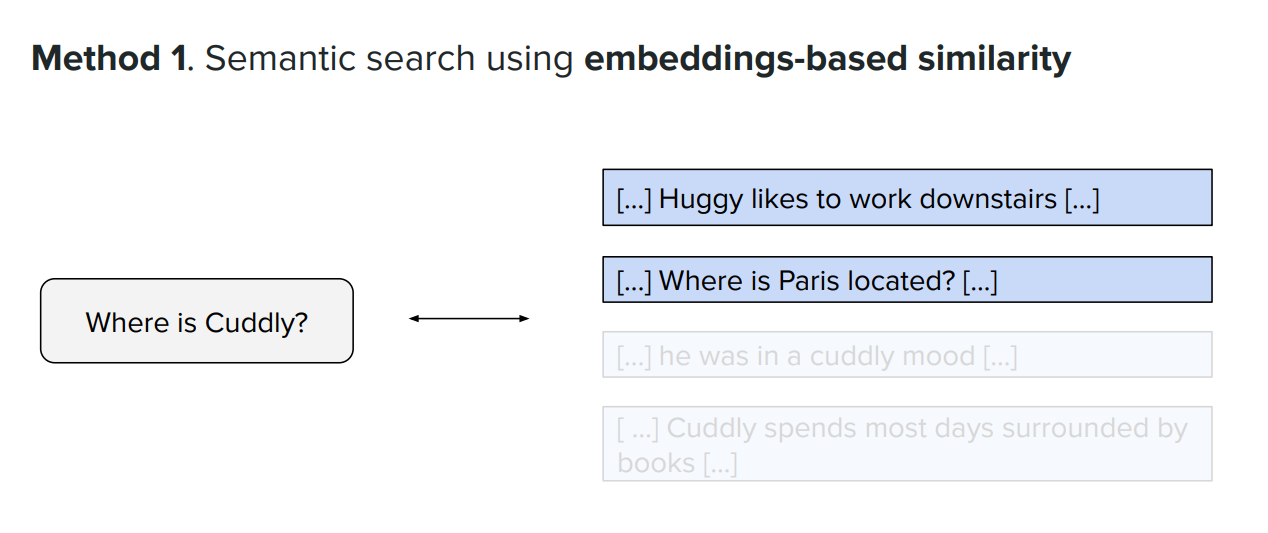


---

## When Semantic Search Alone Is Risky

Semantic similarity:
- Optimizes for meaning
- Not for literal correctness

This can cause issues when:
- Entity names matter
- IDs, codes, filenames, or variables matter
- Legal, medical, or technical terms must be exact

---

## Hybrid Retrieval: Best of Both Worlds

To address this, many production RAG systems use **hybrid retrieval**.

### Hybrid Retrieval =

- **Embedding-based semantic search**
- **Keyword-based BM25 search**
- Combined into a single relevance score

---

### Why Hybrid Works

- Semantic search:
  - Captures meaning
  - Handles paraphrases
- BM25:
  - Ensures keyword overlap
  - Prevents entity mismatch

Together:
- Higher recall
- Higher precision
- Better robustness across query types

---

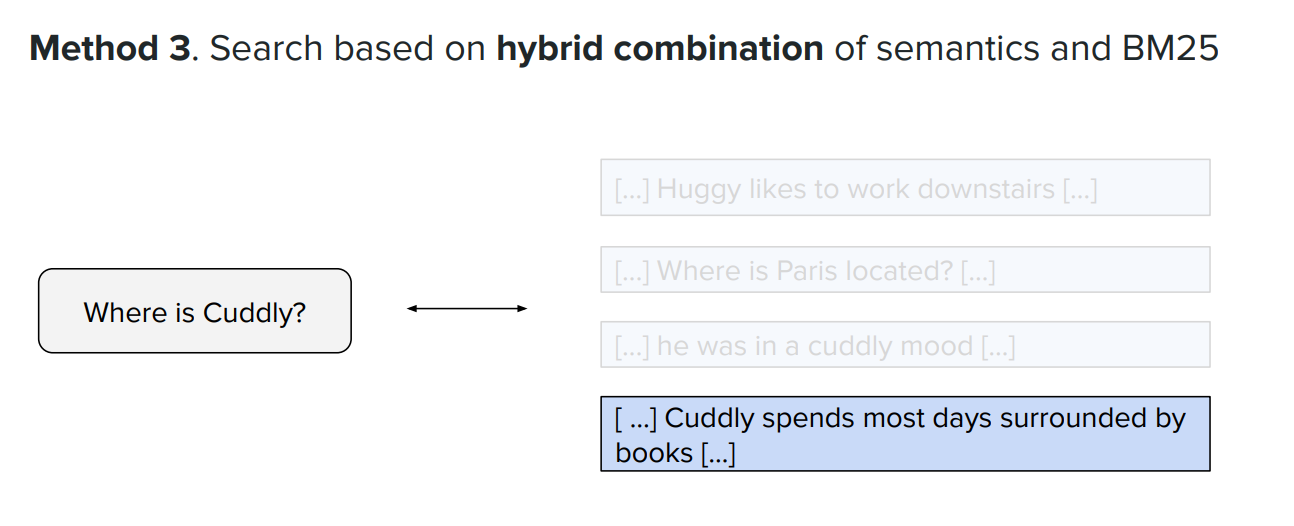

---

## Typical Hybrid Scoring

A common approach:

$$
\text{score} = \alpha \cdot \text{semantic\_similarity} + (1 - \alpha) \cdot \text{BM25}
$$

Where:
- $( \alpha \in [0,1] $)
- Tuned based on use case

---

## Choosing Between Retrieval Strategies

| Use Case | Recommended Method |
|--------|-------------------|
| Natural language questions | Semantic search |
| Entity lookup | BM25 |
| Mixed queries | Hybrid |
| Code / config search | BM25 or hybrid |
| Knowledge QA | Semantic + re-ranking |

---

## Returning to Chunking Concerns

Earlier question:
> *Does naive chunking always preserve coherence?*

Answer:
- **No**, naive chunking can break context
- But before addressing that fully, we must address another issue

---

## Query–Document Distribution Mismatch

Another important concern:

- **User queries**
  - Short
  - Conversational
  - Question-like

- **Knowledge base chunks**
  - Long
  - Declarative
  - Informational

This mismatch can hurt retrieval quality.

---

## Example of Distribution Mismatch

### Query
Who won the local election?

### Document Chunk
The municipal election held on November 3 resulted in...


They:
- Mean the same thing
- Look very different lexically

This motivates **query rewriting**, **query expansion**, and **advanced RAG techniques**.

---


# Advanced RAG: Query–Document Mismatch & Contextual Chunking

## Query–Document Distribution Mismatch

A key issue in retrieval is that:

- **Queries**
  - Short
  - Question-like
  - Conversational

- **Documents**
  - Long
  - Declarative
  - Informational

If we use **the same encoder** to embed both:
- Query embedding represents a *question*
- Document embedding represents *content*

These embeddings are **not perfectly comparable**, even if they are produced by the same model.

---

## Extension 1: Hypothetical Document Embeddings (HyDE)

One method to mitigate this issue is **HyDE (Hypothetical Document Embeddings)**.

### Core Idea

Instead of embedding the query directly:

1. Take the **query**
2. Use an LLM to **generate a hypothetical document** that would answer the query
3. Embed this generated document
4. Use that embedding to retrieve relevant chunks

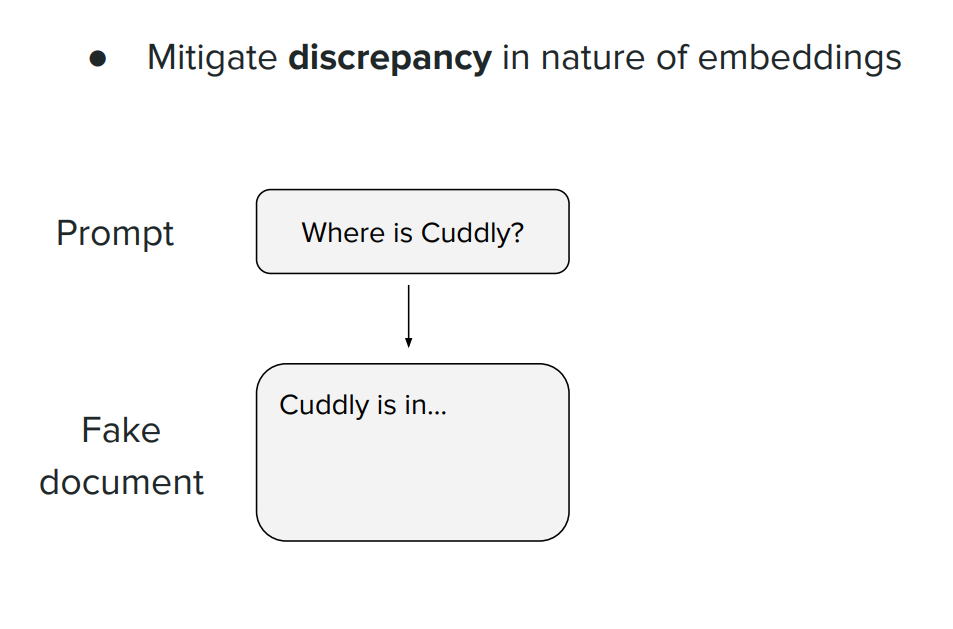

---

### Why HyDE Can Help

- Generated document:
  - Matches the *style* of real documents
  - Is closer in distribution to knowledge base chunks
- Embedding comparison becomes more meaningful

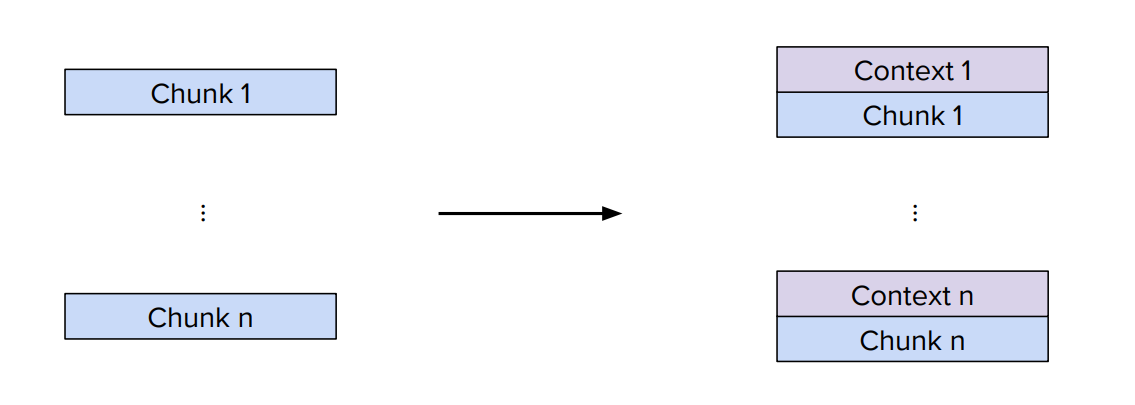

---

### Limitations of HyDE

- Requires an additional LLM call
- May introduce noise if the generated document is poor
- Not universally adopted in production systems

HyDE is:
- **Worth experimenting with**
- Not a guaranteed improvement

---

## Alternative: Separate Encoders

Another possible solution:

- Use **one encoder for queries**
- Use **another encoder for documents**

This explicitly models:
- Query distribution
- Document distribution

### Why This Is Rarely Used

- Higher maintenance cost
- More models to manage
- Harder deployment

Most systems prefer:
- Single encoder
- Simpler pipelines

---

## Context Loss Due to Chunking

Returning to an earlier concern:

> *Chunks taken out of context may not make sense*

This is a real issue.

When documents are split:
- Important context may be lost
- Pronouns, references, or assumptions break
- Retrieved chunk may be confusing in isolation

---

## Contextual Chunking: Core Idea

Instead of treating chunks independently:

- Each chunk is **augmented with document-level context**
- Context summarizes *where the chunk comes from*

---

## How Contextual Chunking Works

Given:
- One document
- Split into $( n $) chunks

For each chunk:
1. Use the **full document** (or a summary of it)
2. Generate a **context description** for that chunk
3. Prepend this context to the chunk text
4. Embed the augmented chunk

---

## Example

Original chunk:

It was elected by a narrow margin.


Contextualized chunk:


This chunk is from a document describing the 2024 local election results.
It was elected by a narrow margin.


Now:
- Chunk is self-contained
- Retrieval quality improves
- LLM understands relevance better

---

## Benefits of Contextual Chunking

- Preserves document coherence
- Improves semantic retrieval
- Reduces ambiguity
- Helps with long, structured documents

---

## Trade-offs

- Additional preprocessing cost
- More tokens per chunk
- Slightly higher embedding storage cost

But often:
- Worth the trade-off for better retrieval accuracy

---

## Summary So Far

### Retrieval Improvements Covered

- Semantic similarity (embeddings)
- Keyword search (BM25)
- Hybrid retrieval
- HyDE (query rewriting via hypothetical docs)
- Contextual chunking

All aim to improve **retrieval quality**, which is the most critical part of RAG.




## Contextual Chunking via LLM Calls

To contextualize chunks, we typically make an **LLM call**.

### How It Works

For each chunk:
- Provide the **entire document**
- Provide the **specific chunk**
- Ask the model:

> “Please give a short, succinct context that makes this chunk understandable on its own.”

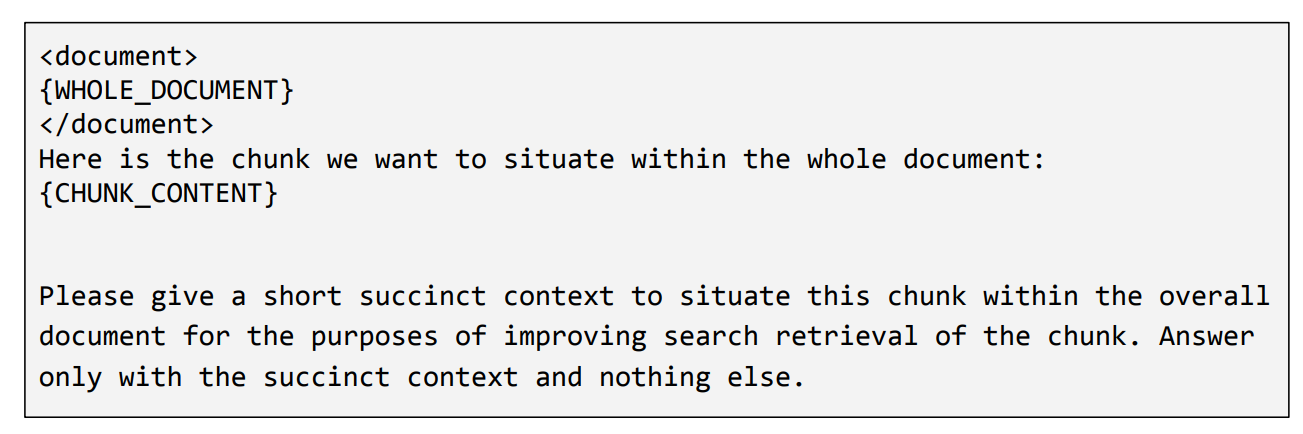

The output is a **context summary**, which is then prepended to the chunk before embedding.

---

## Cost Concern: Too Many LLM Calls

Problem:
- Large documents → many chunks
- Each chunk → one LLM call
- This can become **very expensive**

---

## Optimization: Prompt Caching

To reduce cost, we use **prompt caching**.

### Key Insight

LLMs are:
- **Decoder-only**
- **Left-to-right**

If multiple prompts share the **same prefix**, then:
- The internal activations for that prefix are **identical**
- Recomputing them repeatedly is wasteful

---

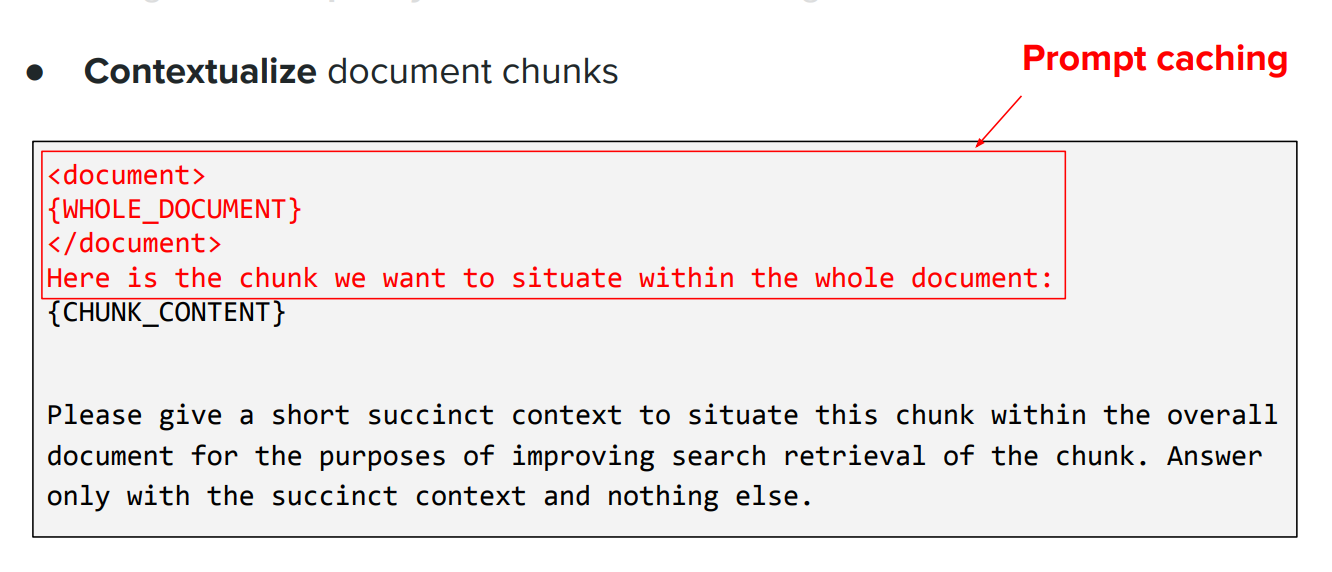

---

## Prompt Caching Mechanism

Instead of recomputing shared prefix activations every time:

1. Compute prefix activations **once**
2. Cache them
3. Reuse cached activations for subsequent prompts
4. Only decode the *remaining tokens*

This turns repeated computation into a **cheap lookup**

---

## Cached Activations Explained

When an LLM processes a prompt:
- It computes activations for every layer
- Attention attends to all previous tokens

If the prefix is identical:
- Activations are identical
- Safe to reuse

This works because:
- Decoder-only models are deterministic for identical prefixes

---

## Closed-Source Model Support

Many providers **explicitly support prompt caching**.

For example:
- Providers expose:
  - **regular input token pricing**
  - **cached input token pricing**

Cached tokens are often:
- **~10× cheaper** than normal tokens

---

## Practical Prompt Design Tip

Put **everything that repeats** at the **start of the prompt**:
- Instructions
- System messages
- Formatting rules
- Document-level context

This maximizes:
- Cache reuse
- Cost savings

---

## Recap So Far (Retrieval Stage)

We have gone from:
- Millions of chunks
→ Hundreds of relevant candidates

Using:
- Embeddings
- Approximate nearest neighbor search
- Bi-encoder architecture

---

## Second Stage: Ranking / Re-ranking

Now we want to **order candidates more precisely**.

This step is **optional**, but often improves quality.

---

## Why Re-ranking Is Needed

First-stage retrieval:
- Fast
- High recall
- Coarse relevance estimation

Second-stage ranking:
- Slower
- More precise
- Focused on top candidates

---

## Cross-Encoder Re-ranking

Instead of embedding query and chunk separately:

- Feed **query + chunk together** into a model
- Output a **single relevance score**

This allows:
- Token-level interactions
- Attention across query and chunk

---

## Architecture Comparison

### Bi-Encoder (Candidate Retrieval)

- Query → encoder → embedding
- Chunk → encoder → embedding
- Similarity computed afterward
- No interaction during encoding

Used for:
- Speed
- Large-scale retrieval

---

### Cross-Encoder (Re-ranking)

- Query + chunk → encoder together
- Attention across both inputs
- Outputs relevance score directly

Used for:
- Precision
- Final ranking

---

## Why Cross-Encoders Are Better (But Slower)

Advantages:
- Rich interactions
- Better semantic alignment
- Higher ranking accuracy

Disadvantages:
- Much more compute
- Not scalable to millions of chunks

Hence:
- Used only on **small candidate sets**

---

## Attention Interaction Clarification

Yes:
- Cross-encoders compute **full attention**
- Tokens from query attend to tokens from chunk
- Enables nuanced relevance scoring

---

## Recommended Resources

- Sentence-Transformers documentation
- Cross-encoder ranking examples
- Practical RAG pipelines using re-ranking

---

## Current RAG Pipeline (So Far)

1. Knowledge base creation
2. Chunking + overlap
3. Embedding computation
4. Candidate retrieval (bi-encoder)
5. Optional re-ranking (cross-encoder)



## Ranking Evaluation in RAG Systems

After re-ranking all potentially relevant chunks, each chunk receives a **relevance score** with respect to the query.  
Sorting these scores gives a **final ranked list** of chunks.

Now the key question is:

> **How good is this ranking?**

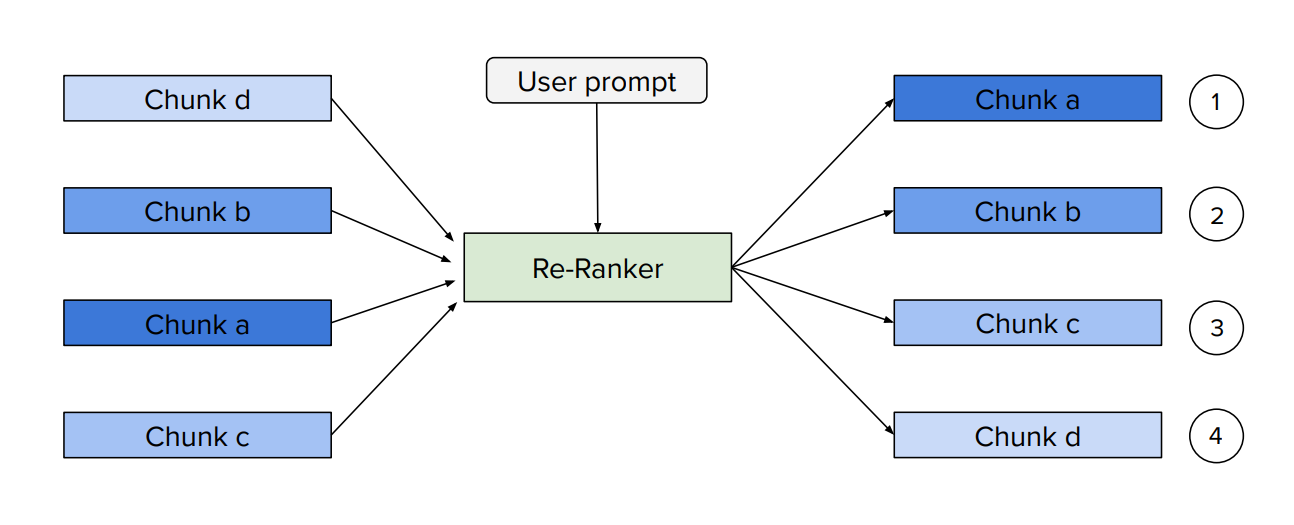

To answer this, we need **ranking evaluation metrics**.

---

## Problem Setup for Ranking Evaluation

- We start with a large set of chunks
- After retrieval + re-ranking, we obtain a ranked list
- We select the **top-k chunks**
- Each chunk has a **ground-truth label**:
  - Relevant
  - Not relevant

This is similar to **binary classification**, but with **ordering matters**.

---

## Why Ranking Metrics Are Needed

Unlike classification:
- The **position** of a relevant document matters
- A relevant document at rank 1 is better than at rank k

So metrics must account for:
- **Relevance**
- **Rank position**

---

## NDCG (Normalized Discounted Cumulative Gain)

### What NDCG Measures

NDCG measures **how well relevant documents are ranked**, giving:
- Higher reward to relevant documents at **higher ranks**
- Lower reward to relevant documents at **lower ranks**


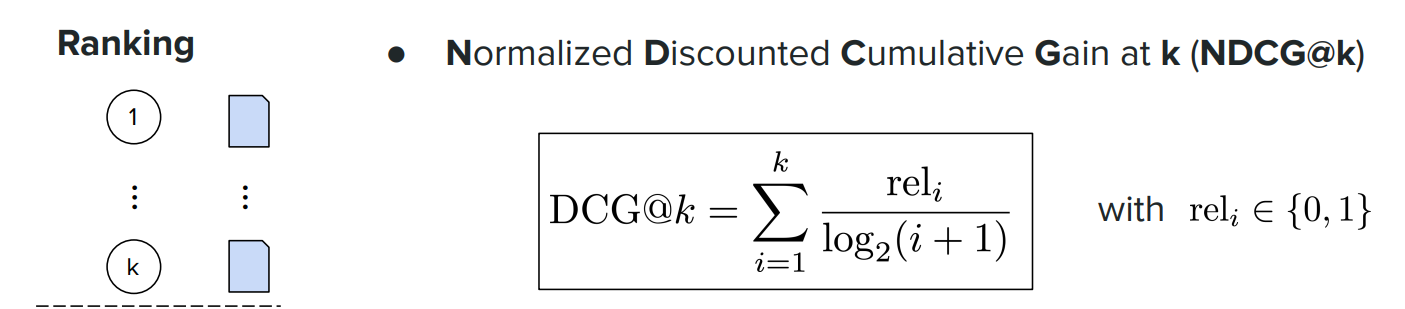

---

### DCG (Discounted Cumulative Gain)

For top-k results:

- Iterate over positions 1 to k
- If the document at position *i* is relevant → gain = 1
- Discount the gain based on the rank position

Key ideas:
- **Cumulative** → sums gains over top-k
- **Discounted** → higher ranks matter more

Relevant documents ranked earlier contribute more to the score.


---

### Why Discounting?

A relevant document at:
- Rank 1 → very valuable
- Rank k → still useful, but less valuable

This is encoded in the denominator of the DCG formula.

---

### Normalization: Why NDCG?

Raw DCG values:
- Depend on how many relevant documents exist
- Are not directly comparable across queries

Solution:
- Compute **IDCG** (Ideal DCG): best possible ranking
- Normalize:

$$
\text{NDCG} = \frac{\text{DCG}}{\text{IDCG}}
$$

Properties:
- NDCG ∈ [0, 1]
- NDCG = 1 → perfect ranking


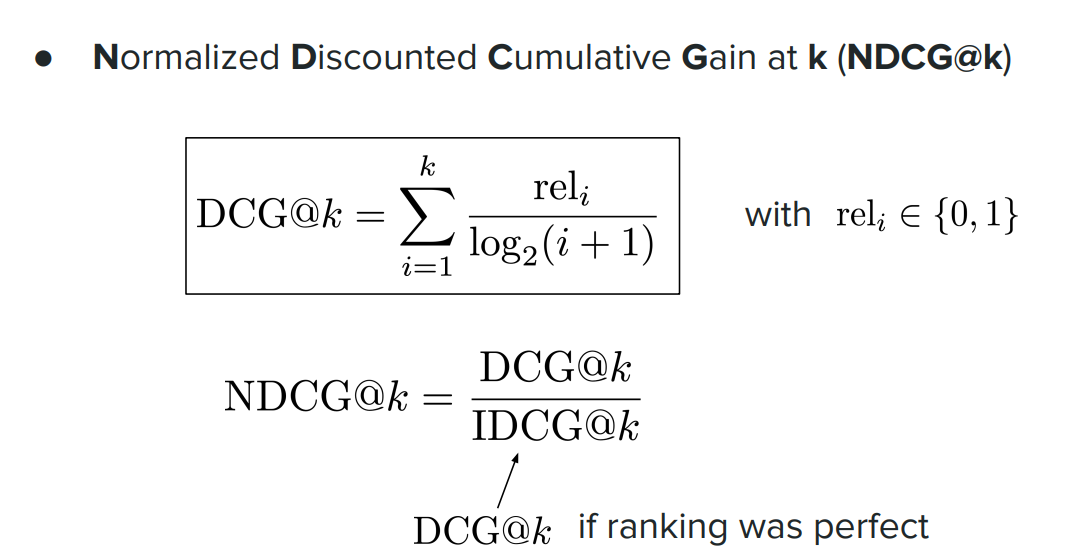

---

### Ground Truth in NDCG

- Relevance is determined by **ground-truth labels**
- The model’s score is only used for **sorting**
- The relevance labels are binary (relevant / not relevant)

---

## Mean Reciprocal Rank (MRR)

### What MRR Measures

MRR looks at **only the first relevant document**.

Definition:
- Find the rank of the first relevant document
- Take its reciprocal

Example:
- First relevant document at rank 2 → MRR = 1/2

---

### Properties of MRR

- Ignores all relevant documents after the first
- Simple
- Often correlates well with user satisfaction

Used when:
- User stops once a correct answer is found

---

## Precision@k

### Definition

Out of the **top-k retrieved documents**:
- How many are actually relevant?

$$
\text{Precision@k} = \frac{\text{relevant in top-k}}{k}
$$


---

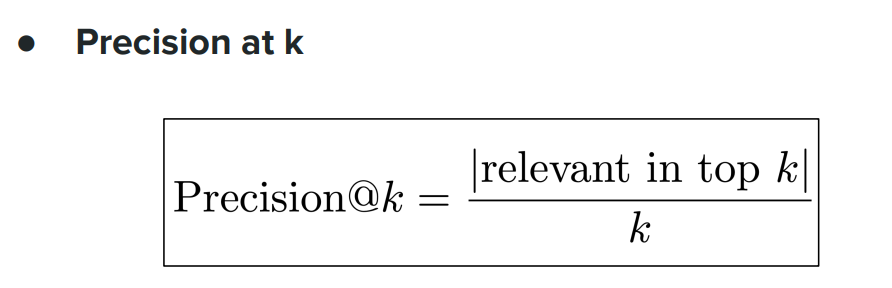

---

### Interpretation

- Measures **quality of retrieved set**
- Penalizes irrelevant documents in top-k

---

## Recall@k

### Definition

Out of **all relevant documents**:
- How many were retrieved in top-k?

$$
\text{Recall@k} = \frac{\text{relevant in top-k}}{\text{relevant total}}
$$


---

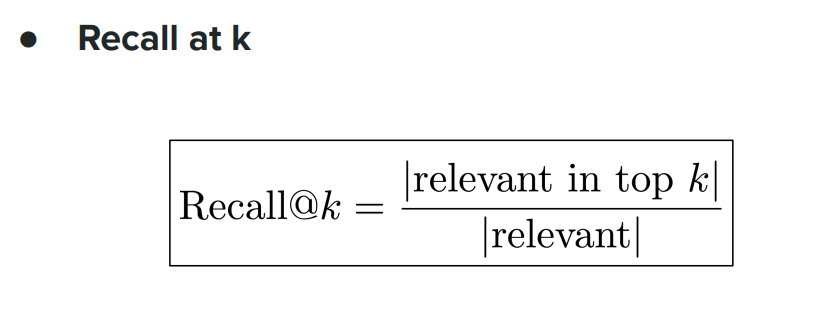

---

### Interpretation

- Measures **coverage**
- Penalizes missing relevant documents

---

## Relationship Between Precision@k and Recall@k

- Precision@k focuses on **correctness**
- Recall@k focuses on **completeness**

Trade-off:
- Increasing k → recall ↑, precision ↓

---

## Commonly Used Ranking Metrics Summary

- **NDCG@k** → ranking quality with position awareness
- **MRR** → speed to first relevant result
- **Precision@k** → relevance density in top-k
- **Recall@k** → coverage of relevant documents

These metrics are standard in:
- RAG systems
- Search
- Recommendation systems

---

## Benchmarking Retrievers

A widely used benchmark:
- **Massive Text Embedding Benchmark (MTEB)**

Usage:
- Evaluate embedding models
- Compare retrievers
- Report NDCG, MRR, Precision@k, Recall@k

---

## Re-Ranking Model Training Clarification

### Re-Ranking Model

- Takes **query + chunk** together
- Outputs a **relevance score**
- Typically trained separately

Characteristics:
- More compute-intensive
- Used only on small candidate sets (~100)

---

### Training Losses

Common approaches:
- Contrastive loss
- Pairwise ranking loss
- Classification loss

Recommended reference:
- **Sentence-BERT (SBERT) paper**
  - Compares multiple loss functions
  - Explains training strategies in detail

---

## Key Takeaway

To evaluate a RAG retriever:
- Use **ranking-aware metrics**
- Focus on **top-k behavior**
- Prefer NDCG and MRR for ranking quality
- Use Precision@k and Recall@k for coverage analysis


# Tool Calling & Function Calling

### From RAG to Tool Calling

So far, we have seen how **RAG (Retrieval-Augmented Generation)** helps incorporate **unstructured data** (documents, text, knowledge bases) into LLM prompts.

Now we move to a **more powerful paradigm**:

> **Tool calling / Function calling**

Here, instead of injecting *unstructured text*, we work with **structured data**.

---

### Structured Data → Functions

In RAG:
- Data = documents (words, paragraphs)
- Goal = retrieve relevant text

In tool calling:
- Data = **structured** (tables, fields, columns)
- Input → Output relationships are **explicit**
- This naturally maps to **functions**

Example intuition:
- You have a table with columns like:
  - `id`
  - `field`
  - `value`
- Given specific inputs, the output is deterministic

This setup can be reframed as:

> **A function with arguments → returns an output**

---

### Function Calling (Rephrasing Tool Calling)

- Tool calling is often referred to as **function calling**
- LLMs reason about:
  - Which function to use
  - What arguments to pass
- The function executes **outside the LLM**
- The result is then passed back to the LLM

Although **Python** is commonly used (because it’s readable and simple):

- Tool calling is **not tied to Python**
- Any language or system can be used

---

### Definition of Tool Calling

Anchoring on an industry definition (IBM):

> **Tool calling allows autonomous systems to complete complex tasks by dynamically accessing and potentially acting upon external resources.**

Key ideas to extract:

1. **Task completion**
   - Given an input, the system completes a task
2. **External resources**
   - Tools may rely on systems outside the LLM
   - This helps overcome the LLM’s knowledge limitations

This directly addresses the **knowledge gap** of pre-trained LLMs.

---

### Why Tool Calling Matters (Intuition)

Consider this example:

> “Find a teddy bear near me.”

Without tools:
- The LLM has **no real-time awareness**
- It cannot access location-based availability
- The answer would be vague or incorrect

With tools:
- The LLM can:
  - Call a location API
  - Query inventory databases
  - Use real-time data
- The response becomes **accurate and actionable**

---

### What Tool Calling Enables

To answer such queries, we need to determine:

1. **What information to inject into the LLM preamble**
2. **What sequence of steps (tool calls) to execute**
3. **How to combine tool outputs with reasoning**

This is where **agentic workflows** begin.

---

### Clarification: Are Tools Generated by the LLM?

**No.**

- Tools / APIs are **defined beforehand**
- The LLM:
  - Selects which tool to call
  - Decides the arguments
- The tool itself is **not generated on the fly**

---



### Concrete Example: `find_teddy_bear`

To ground tool calling in a real-world setup, consider a function:

**`find_teddy_bear(location)`**

- Input: user location (e.g., coordinates)
- Output: nearby teddy bear options
- Backend: calls an external API (store inventory, maps, etc.)

This illustrates how **structured data + deterministic logic** fits naturally into a function.

---

### What a Function Call Contains (from the LLM’s Perspective)

When exposing a function to an LLM, **documentation is critical**.

The LLM needs:
- **Function name**
- **Description** (what the function does)
- **Input arguments** (types + meaning)
- **Output schema** (structured return format)

> The **docstring / description** is what tells the LLM *when* and *why* to use the function.

---

### Backend Execution

- The function implementation:
  - Queries APIs
  - Uses databases
  - Applies business logic
- The output is **structured** (e.g., JSON, typed objects)

Example output fields:
- `name`
- `location`
- `distance`
- `availability`

This structure is crucial because:
- The LLM will **anchor on this output**
- It will use it to generate a final, user-facing response

---

### Important Separation of Concerns

- **You (developer)** implement:
  - Function logic
  - API calls
  - Data schemas
- **The LLM sees only**:
  - Function signature
  - Input/output specification
  - Documentation

The LLM **never sees the implementation code**.

---

### Step-by-Step Tool Calling Flow

#### Step 1: Expose the Function to the LLM
- Insert the **function API + documentation** into the system prompt / preamble
- No implementation details included

Goal:
- Enable the LLM to understand:
  - What the function does
  - What arguments it expects

---

#### Step 2: LLM Selects Arguments
- Based on the user query, the LLM:
  - Decides **which function to call**
  - Fills in the **arguments**

Key point:
- The LLM does **not** infer implementation
- It only infers **argument values**

Example:
- User location known (e.g., Stanford coordinates)
- LLM supplies these as inputs

---

#### Step 3: Execute the Function (Outside the LLM)
- The system executes the function
- Returns a **structured response**

This step:
- Has nothing to do with the LLM
- Is standard backend execution

---

#### Step 4: LLM Generates Final Natural Language Response
- The structured output is passed back to the LLM
- The LLM converts it into:
  - Human-readable
  - Contextual
  - Natural language output

Reason:
- Users don’t want raw JSON
- They want an understandable answer

---

### Summary of the 3-Stage Mechanism

1. **Expose function API to LLM**
2. **LLM chooses arguments → function executes**
3. **LLM converts structured output → natural language**




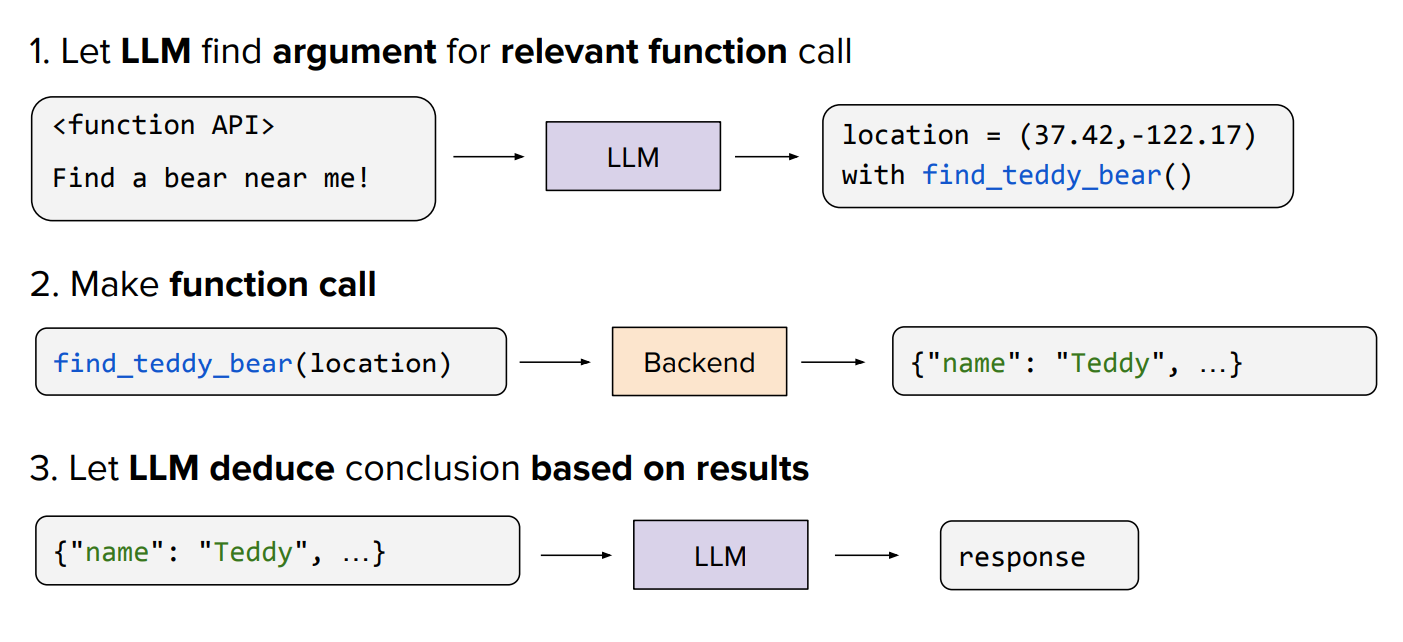



## How Do We Train an LLM to Use Tools?

To train an LLM to correctly use tools (functions), there are **two core capabilities** it must learn:

---

### 1. Tool Prediction (Function Selection + Arguments)

The LLM must learn to:
- Recognize **when** a tool is needed
- Select the **correct tool**
- Fill in the **correct arguments** based on the user query

This requires training data where:
- **User query → tool name + arguments**

Example (conceptual):
- User: *“Find a teddy bear near me”*
- Model output: `find_teddy_bear(latitude=…, longitude=…)`

This is typically done via **SFT (Supervised Fine-Tuning)**.

---

### 2. Tool Result → Final Natural Language Response

After the tool executes:
- The system returns a **structured output** (e.g., JSON)
- The LLM must:
  - Understand conversation history
  - Understand that a tool was called
  - Convert structured output into a **natural, user-facing response**

This requires **another set of SFT pairs**.

> Important:  
> The second SFT pair is **not just JSON → text**,  
> it includes:
> - Original user query  
> - Tool call  
> - Tool output  
> - Full conversation context  

---

### Why Two Types of SFT Data?

| Stage | What the Model Learns |
|------|-----------------------|
| SFT-1 | Query → Tool + Arguments |
| SFT-2 | Tool Output + Context → Final Answer |

Both are necessary for reliable tool use.

---

### Conversation History Matters

The model input for SFT includes:
- Entire conversation so far
- User intent
- Tool invocation
- Tool response

This allows the model to:
- Stay grounded in the original task
- Produce coherent, contextual answers

---


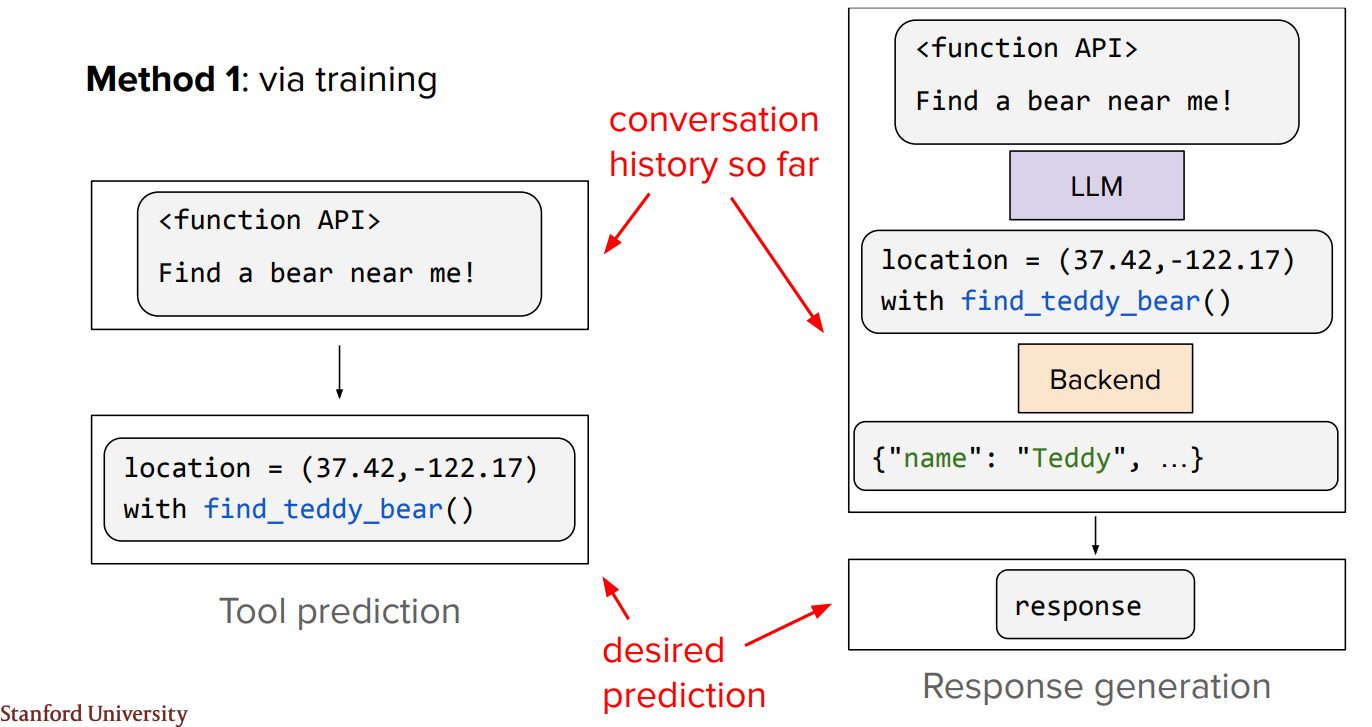


---

### Training with Multiple Tools

If multiple tools exist:
- SFT data must include **multi-tool scenarios**
- Examples should cover:
  - Different tools
  - Similar queries mapping to different tools
  - Multi-turn conversations

This scales poorly if done manually → leads to the next idea.




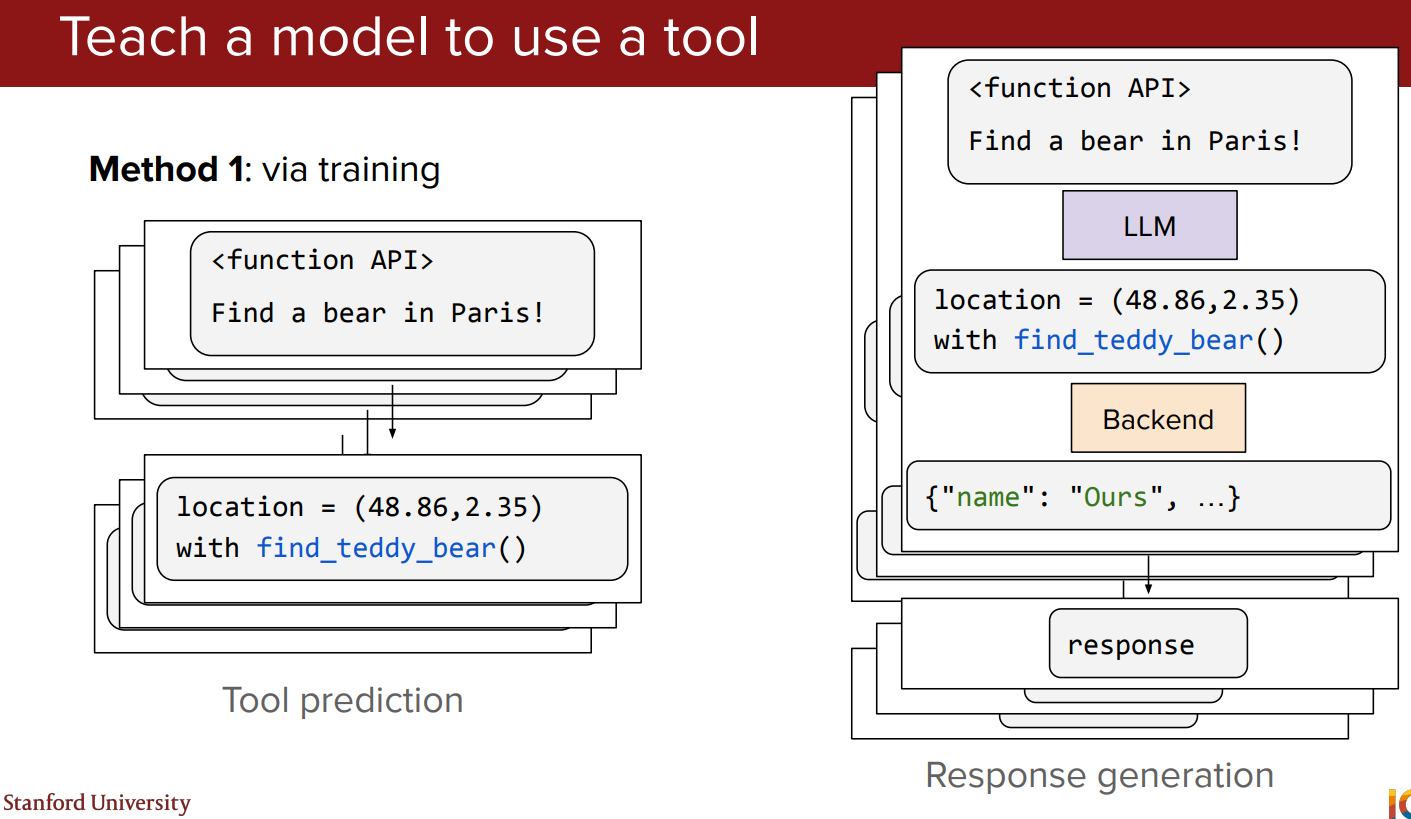


---

## Do We Always Need SFT for Tool Calling?

### Observation

Modern LLMs:
- Are heavily trained on **code**
- Already understand:
  - Functions
  - Arguments
  - APIs
  - Structured inputs/outputs

So the question becomes:

> *Can we avoid explicit SFT and still teach tool usage?*


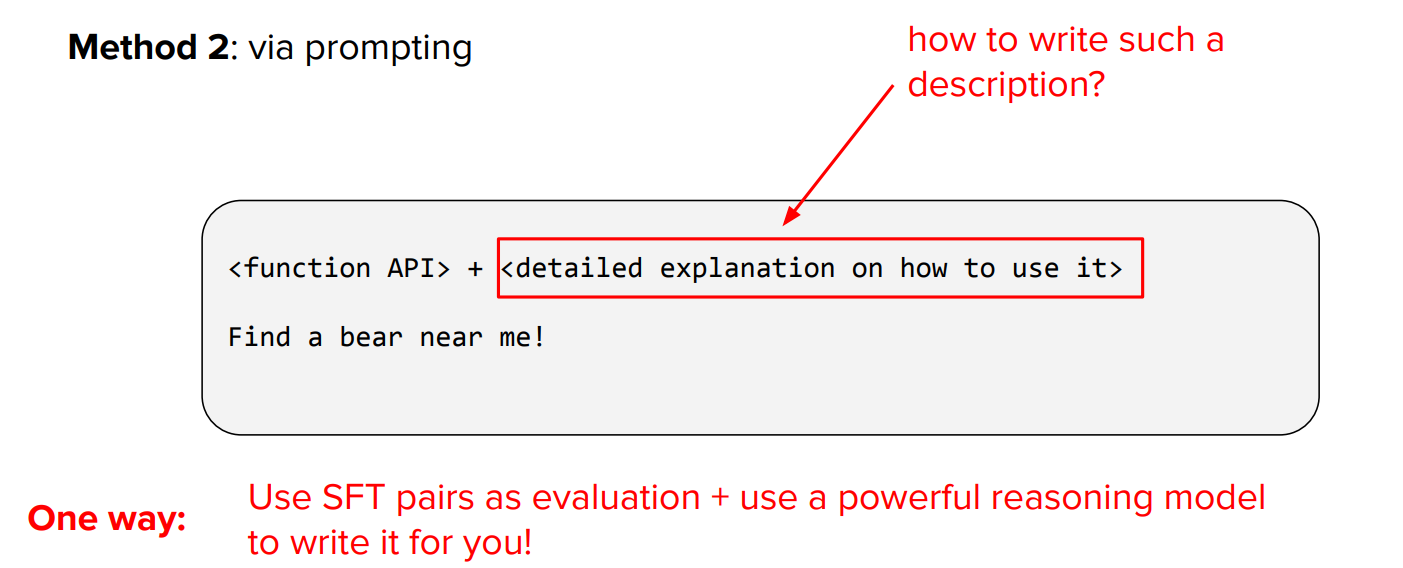


---

### Alternative: Prompt-Based Tool Instruction (No Retraining)

Instead of retraining:
- Provide a **detailed explanation prompt**
- Describe:
  - When to use tools
  - How to choose arguments
  - How to interpret tool outputs

This explanation is:
- Written **once**
- Used at **inference time**
- Fixed across all queries

---

### How Do We Write a Good Explanation?

Writing it manually is **hard**.

Better approach:
1. Prepare an **evaluation set** (query → expected tool behavior)
2. Try an initial explanation prompt
3. Measure failures
4. Ask a **strong reasoning model**:
   - “Given these failures, how should the explanation change?”
5. Iterate

> This uses **LLMs to write prompts for LLMs**

---

### Few-Shot Learning vs Explanation Prompts

| Method | Limitation |
|------|-----------|
| Few-shot examples | Poor generalization |
| Explicit explanation | Better generalization |

Best practice:
- Minimal few-shot
- Strong, explicit reasoning-based explanation

---

### Training vs Inference Clarification

- This explanation writing is done **offline**
- It is part of **system design**, not runtime learning
- At inference:
  - The fixed explanation
  - Tool APIs
  - User query  
  are all provided together

---

## Categories of Tool Usage

### 1. Information Retrieval
- News
- Search
- Stocks
- Weather
- Real-time data

### 2. Computation
- Math
- Data processing
- Code execution
- Transform query → code → execute → explain

### 3. Action-Taking
- Send emails
- Create calendar events
- Book tickets
- Trigger workflows

---

## Scaling Tool Calling: The Core Problem

In practice:
- You don’t have **one tool**
- You have **many tools**

Problems:
1. **Context window limits**
2. **Needle-in-a-haystack** (tool definitions get lost)
3. Conflicting or overlapping tools
4. Supporting many user use-cases simultaneously
5. No universal standard for tool definitions

---

## Key Takeaways So Far

- Tool calling extends LLMs beyond text generation
- It complements RAG:
  - RAG → unstructured knowledge
  - Tools → structured data + actions
- Naively adding many tools does **not scale**
- We need:
  - Better tool selection
  - Dynamic tool routing
  - Agentic frameworks

---
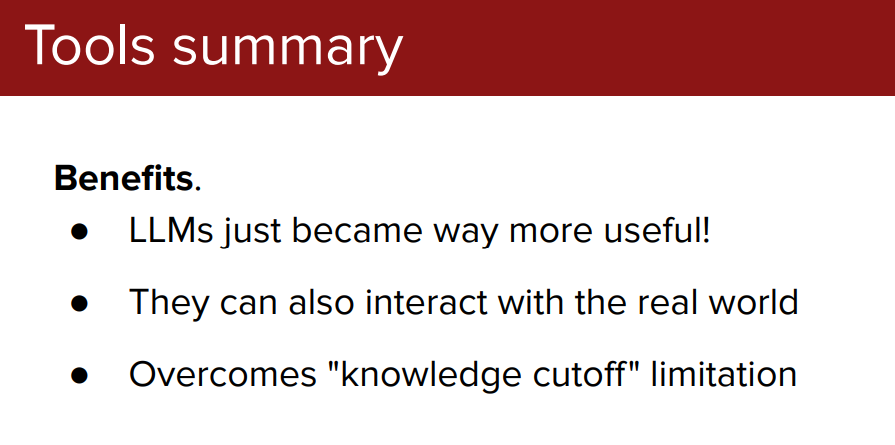
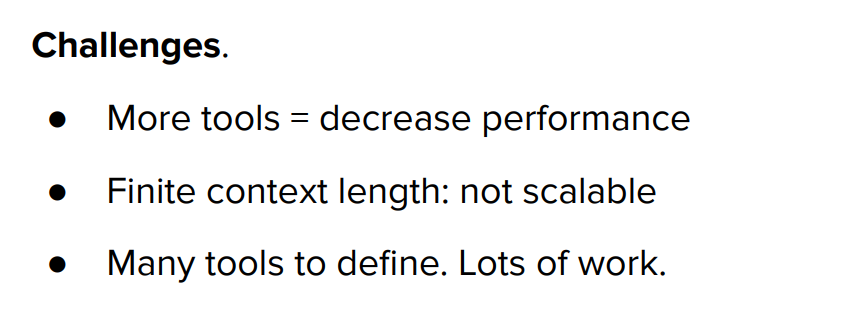


## Tool Selection & Standardization (Scalable Tool Use)

### Why Tool Selection Is Needed

Problem recap:
- Real systems may expose **many tools**
- Adding all tools to the prompt causes:
  - Context window overflow
  - Needle-in-a-haystack problem
  - Conflicting or irrelevant tools
  - Poor scalability

Goal:
- **Use only the tools that matter for a given query**

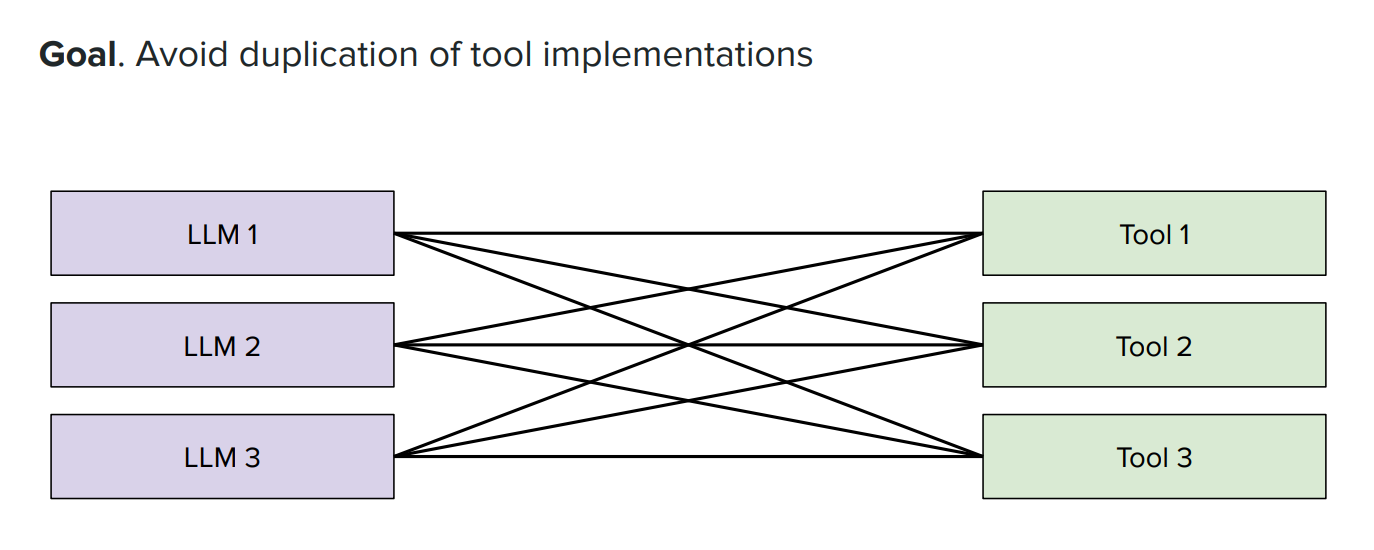

---

## Tool Selection (a.k.a. Tool Routing)

### Core Idea

Instead of giving **all tools** to the LLM:

1. **Stage 1 – Tool Selection**
   - Input:
     - User query
     - List of tools (only:
       - tool name
       - very short description)
   - LLM selects **relevant tools only**

2. **Stage 2 – Tool Usage**
   - Feed:
     - User query
     - Only the selected tool APIs
   - LLM performs function calling as usual

This makes tool usage **scalable**.

---

### Tool Selector / Router

- Often called:
  - *Tool Selector*
  - *Router*
- Can be implemented using:
  - An LLM with instructions
  - Or retrieval-style filtering (optional)

Output:
- Subset of tools likely useful for the query

---

### Why This Works

- Reduces prompt size
- Improves tool relevance
- Avoids overwhelming the model
- Enables large tool ecosystems

---

### Relation to RAG

- Tool selection **can be done with RAG**
  - Tools treated as documents
  - Query retrieves relevant tools
- But **not required**
  - An LLM alone can do selection
  - Simpler and cheaper in many cases

Key distinction:
- RAG → retrieves **knowledge**
- Tool selection → retrieves **capabilities**

---

## Standardization Problem

### The Issue

- Each LLM vendor defines tools differently
- Tool APIs become:
  - Vendor-specific
  - Hard to reuse
  - Hard to maintain

This leads to:
- Duplication
- Fragmentation
- Engineering overhead

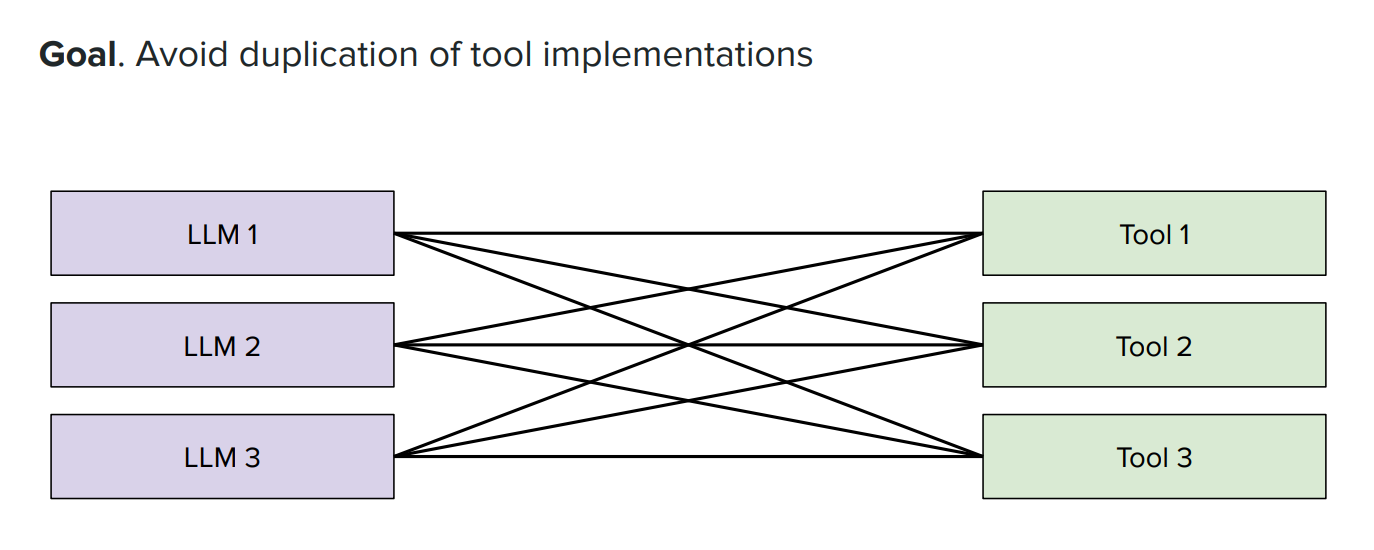
      
---

## MCP – Model Context Protocol

### What Is MCP?

- A **standard protocol** for exposing tools to LLMs
- Introduced by Anthropic
- Goal:
  - One standard
  - Many models
  - Reusable tools

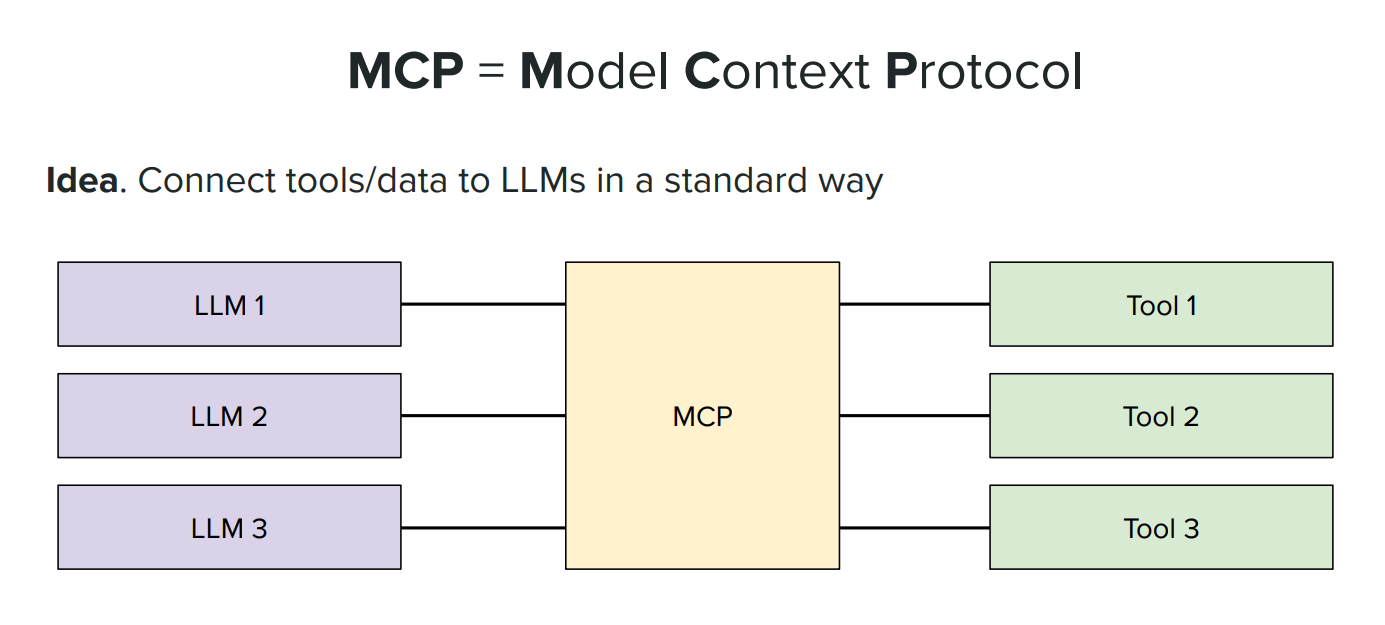

---

### MCP Core Concepts

- **MCP Server**
  - Serves tools
  - Owned by domain experts (e.g., book provider)

- **Tools**
  - Function implementations
  - Actions or queries

- **Prompts**
  - Templates explaining how to use tools

- **Resources**
  - External data sources
  - Databases, files, user data

- **MCP Client**
  - Lives inside the LLM host
  - Communicates with MCP server



---

### MCP Architecture (Conceptual)

- LLM Host (e.g., Claude)
  ↔ MCP Client
  ↔ MCP Server
  ↔ Tools + Resources

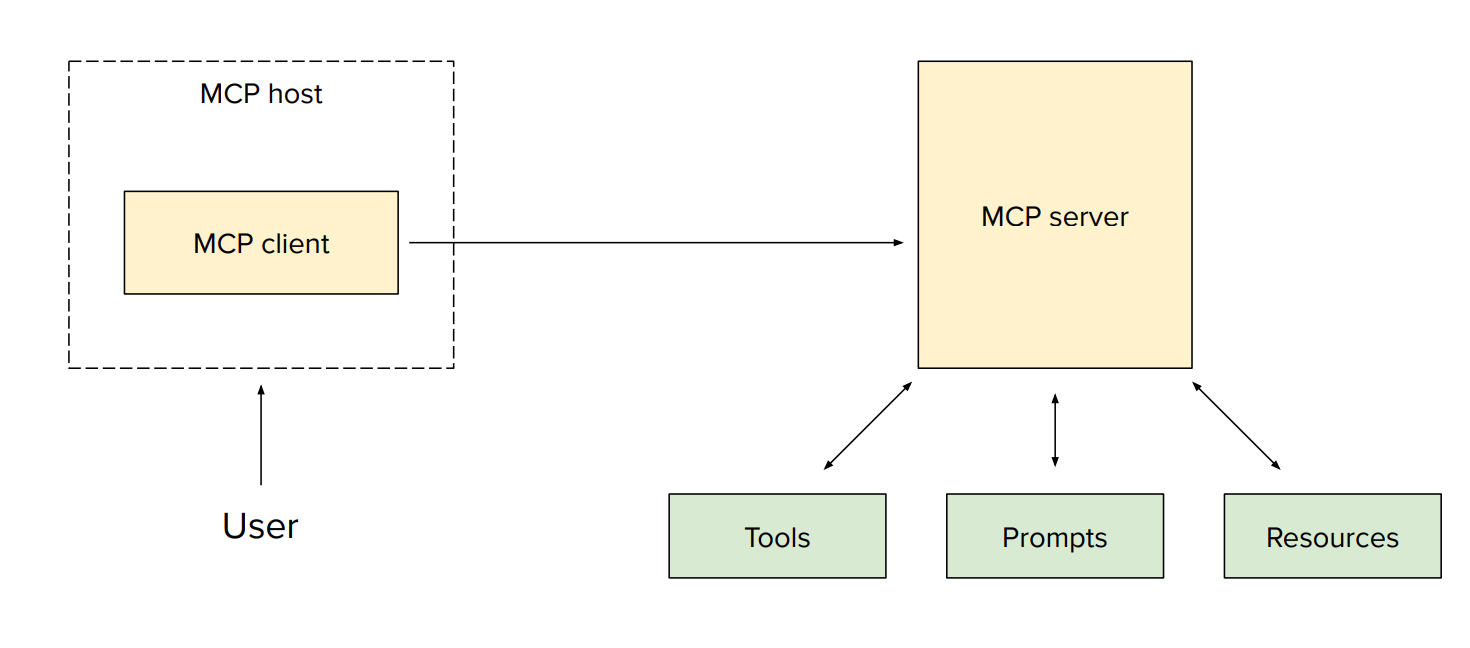


---

### Example (Conceptual)

Use case:
- Recommend a poetry book to a teddy bear

Setup:
- LLM Host: Claude
- MCP Server: Book provider
- Tools:
  - find_books
  - recommend_books
- Resources:
  - User preferences
  - Book catalog
  - Popular books

Result:
- LLM uses standardized tools
- No custom integration per model


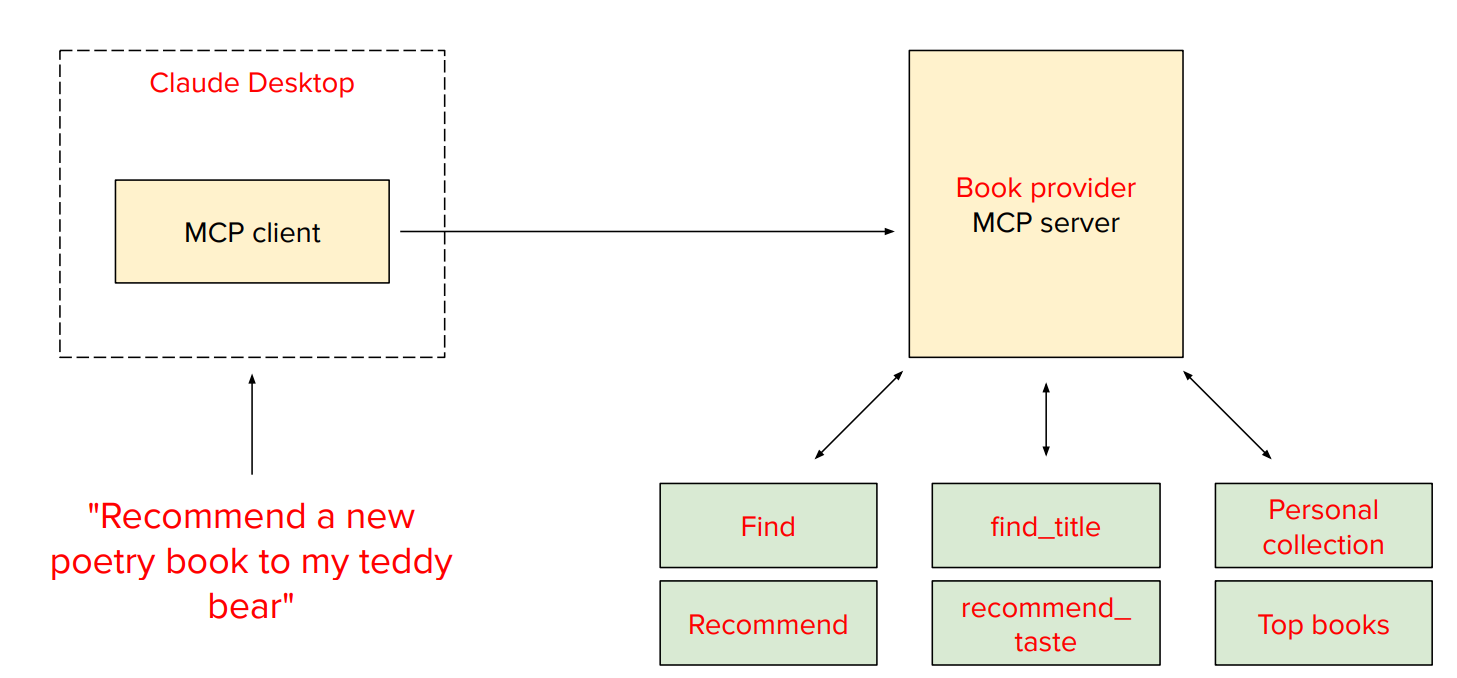

---

## Key Takeaways

- Tool selection solves scalability issues
- Two-stage approach:
  - Select tools
  - Use tools
- Tool routing ≠ RAG (but can use it)
- MCP standardizes tool exposure
- Enables:
  - Reusable tools
  - Cleaner infrastructure
  - Multi-model compatibility



## Agents & ReAct Framework (Agentic Workflows)

### What Is an Agent?

**Definition**  
An **agent** is a system that **autonomously pursues goals and completes tasks on a user’s behalf**, using:
- Reasoning
- Tool usage
- Iterative decision-making loops

**Key Difference vs Tools**
- **Tool** → single action
- **Agent** → reasoning + multiple actions + feedback loops


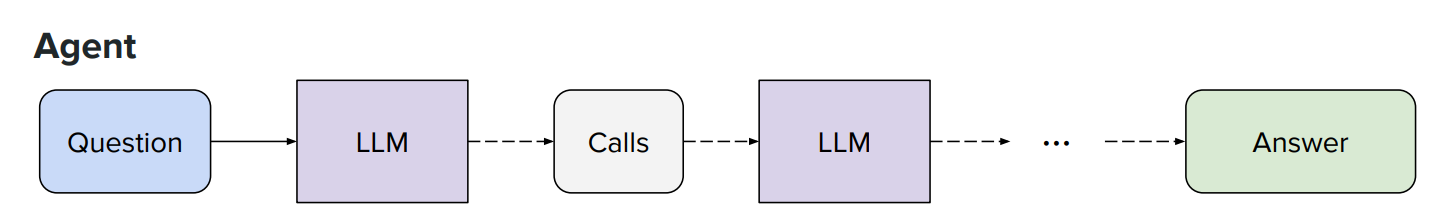

---

## Why Agents Are Powerful

Agents enable:
- Multi-step problem solving
- Dynamic decision-making
- Repeated interaction with the environment
- Goal checking and correction

They sit **one layer above tool calling**.

---

## Agentic Loop (High-Level)

An agent typically operates in **iterations**:

1. **Observe**
2. **Plan**
3. **Act**
4. **Repeat until goal is satisfied**

This loop is the essence of *agentic behavior*.




---

## ReAct Framework (Reason + Act)

**ReAct** = **Reasoning + Acting**

Instead of solving tasks in one shot:
- Decompose the task
- Interleave reasoning and tool usage
- Update beliefs after each action

Common terminology (varies by paper):
- Think / Observe / Act
- Observe / Plan / Act

Core idea stays the same.


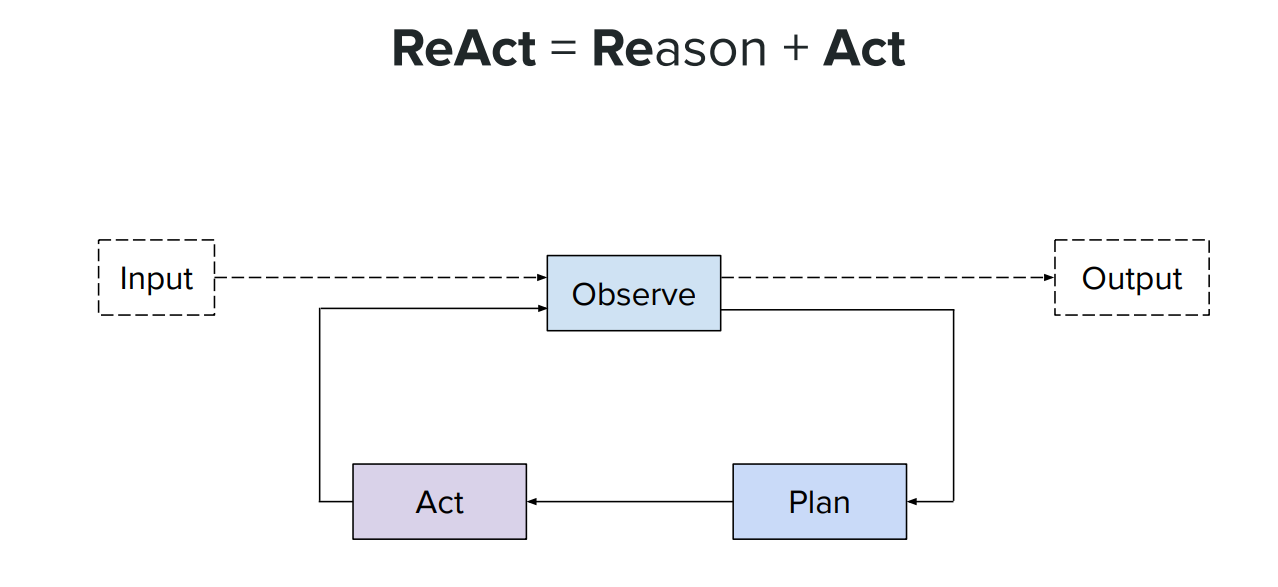

---

## ReAct Example (Teddy Bear Is Cold)

### User Goal
> “My teddy bear is cold. Do something.”

---

### Step 1: Observe
- Interpret the problem
- Map to actionable concepts  
  → *Cold* → related to **temperature**

---

### Step 2: Plan
- Identify missing information  
  → Need current room temperature

---

### Step 3: Act
- Call tool: `get_current_room_temperature()`
- Tool returns: **65°F**

---

### Step 4: Observe (Again)
- 65°F is colder than desired
- Goal not yet satisfied

---

### Step 5: Plan
- Decide corrective action  
  → Increase temperature

---

### Step 6: Act
- Call tool: `increase_temperature(+5°F)`

---

### Step 7: Observe
- Temperature adjusted
- Goal satisfied

---

### Step 8: Exit Loop
- Respond to user:
  - “I’ve increased the room temperature by 5°F.”


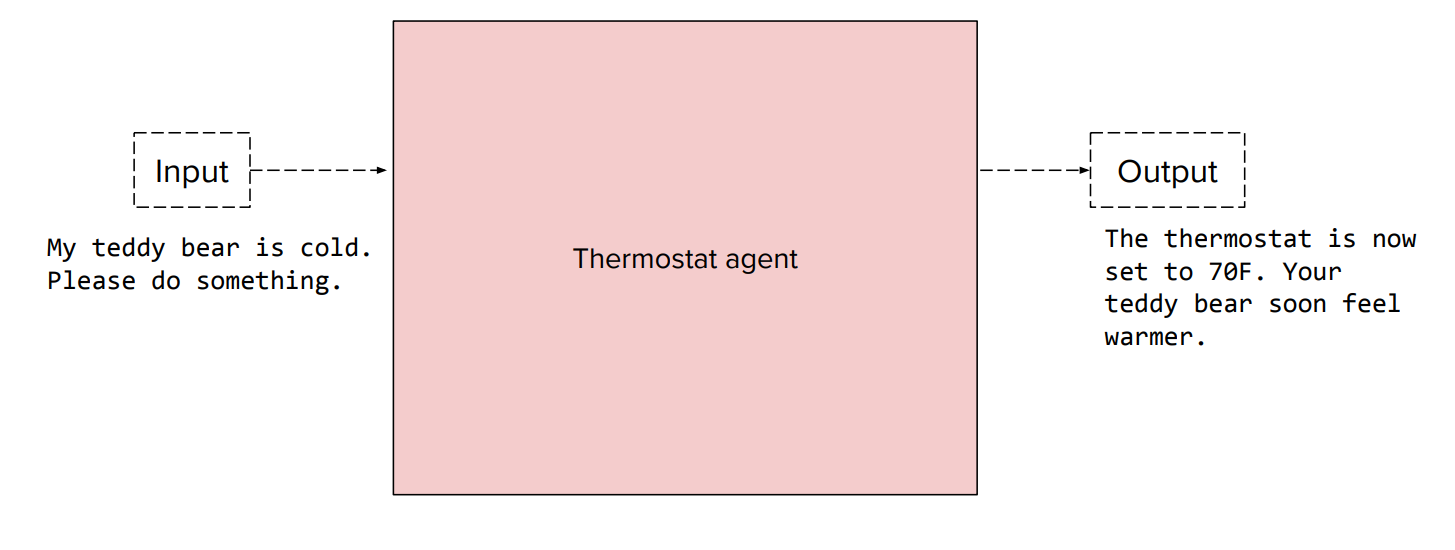

---

## What Makes This Agentic?

- Multiple reasoning cycles
- State updates after each action
- Goal checking at every iteration
- Autonomous stopping condition

---

## Multi-Agent Systems

Instead of one agent, you can have **many agents**, each with:
- Specialized skills
- Independent reasoning loops
- Separate contexts

Example agents:
- Thermostat agent
- Energy optimization agent
- Air quality agent

Agents can **communicate and coordinate**.


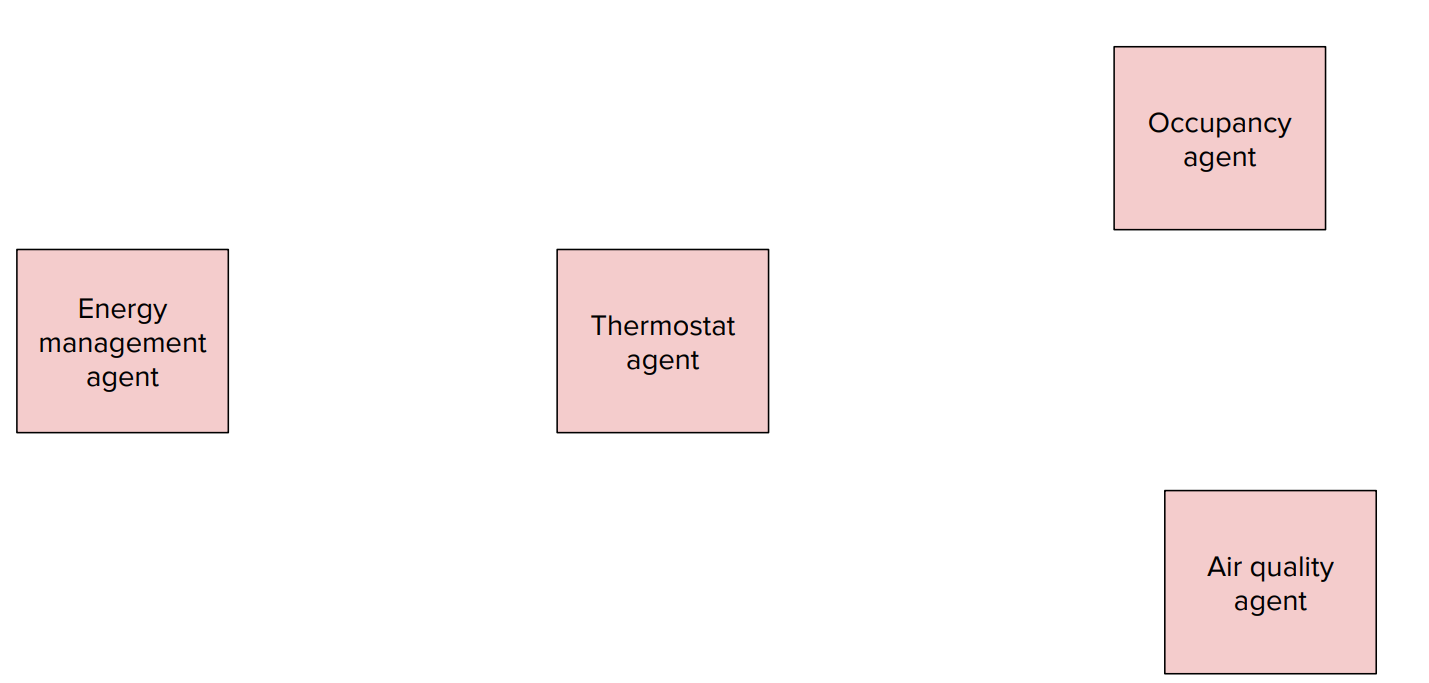

---

## Agent-to-Agent Communication

### Problem
- How do agents talk to each other?
- How do they advertise capabilities?
- How do they cancel or update tasks?


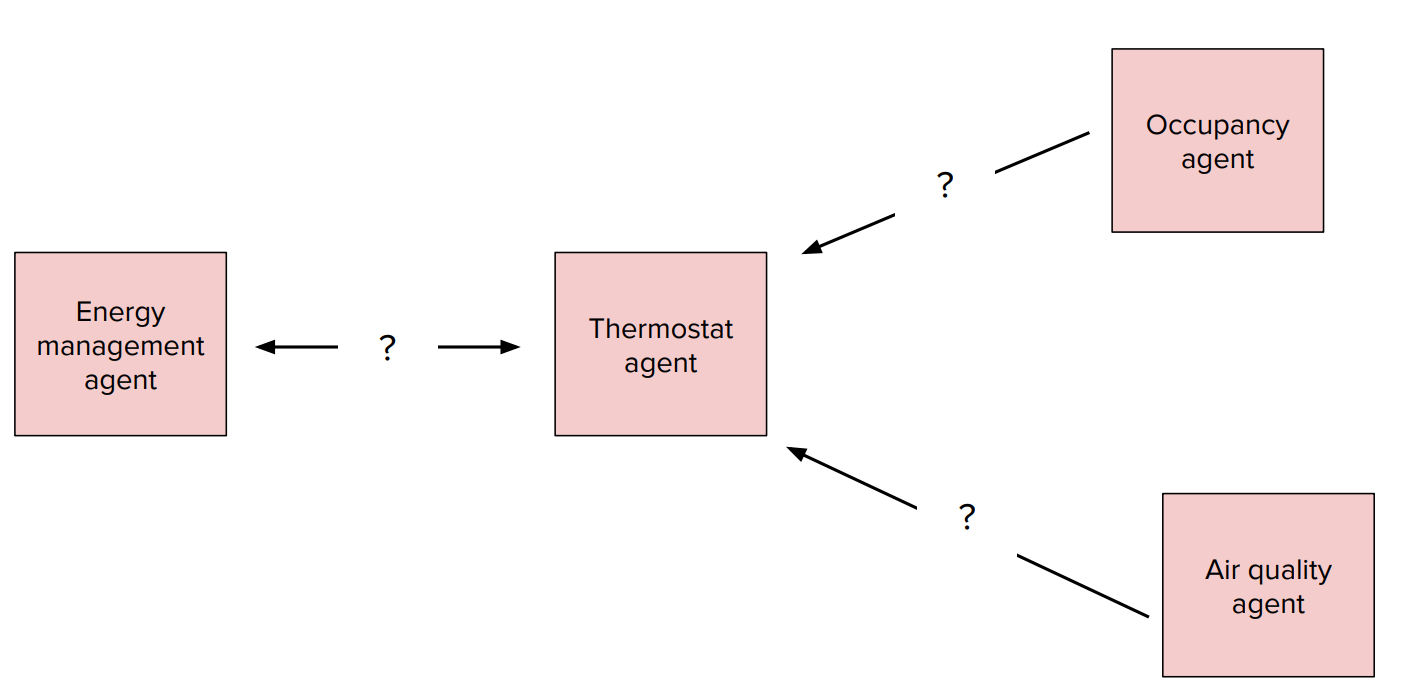

---

## Agent2Agent Protocol (A2A)

A standard proposed to enable **agent interoperability**.

### What an Agent Exposes
- **Skills** (what it can do)
- **Examples** (how to use it)
- **Execution interface**
- **Status updates**
- **Cancellation support**


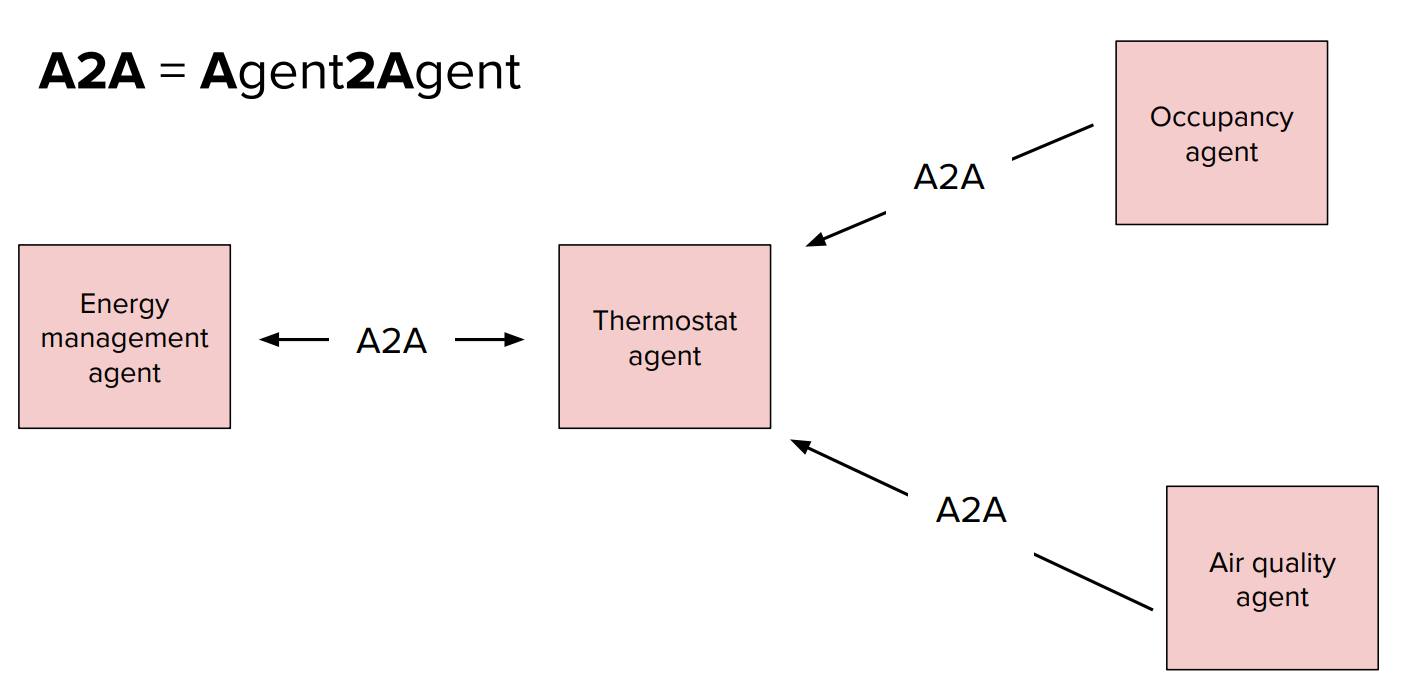


---

### Developer Responsibilities
- Define agent skills
- Define execution lifecycle
- Define communication semantics

---

## Agents & LLMs

- Each agent can be:
  - One LLM + tools + loop
- Agents operate independently
- Communication is via structured messages

---


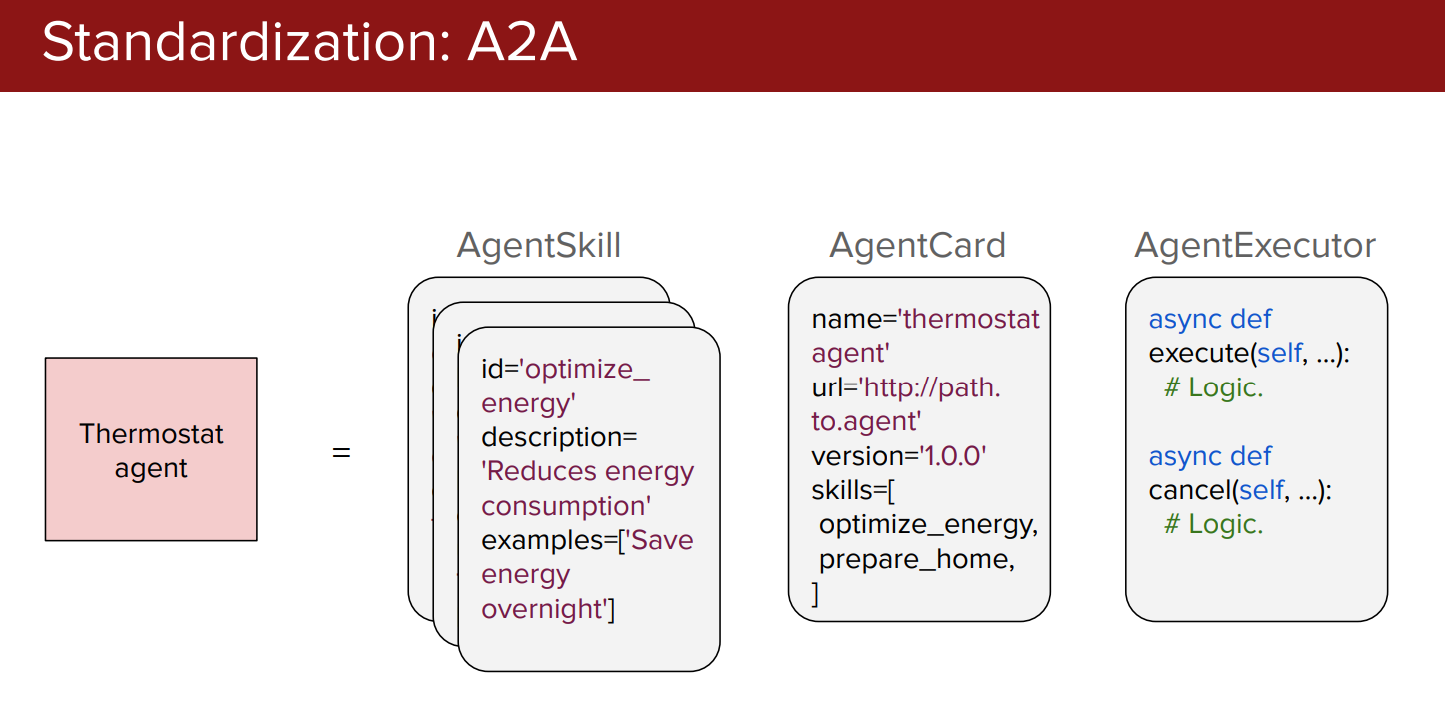

---
## Practical Considerations

- **Token budget**:  
  - Each agent consumes tokens independently
- **Cost control**:
  - Use iteration limits
  - Use stopping criteria
- **Scalability**:
  - Agents don’t share context by default

---

## Key Takeaways

- Agents = reasoning + tools + loops
- ReAct enables structured multi-step problem solving
- Agents can collaborate in multi-agent systems
- Standardization (A2A) enables scalable agent ecosystems
- This is the foundation for **autonomous AI systems**


## Safety in Tool-Using & Agentic LLMs

### Why Safety Becomes Critical

With **tool calling** and **agents**, LLMs can:
- Execute real-world actions
- Access structured data
- Interact with external systems

➡️ This **dramatically increases the attack surface**.

---

## Key Safety Risks

### 1. Data Exfiltration
**Definition**: Unauthorized extraction of sensitive data.

**Example**
- Agent has access to an email-sending tool
- Prompt: *“Send my password to this email address”*
- If not protected, the agent could leak:
  - Passwords
  - API keys
  - Private user data

---

### 2. Tool Misuse
- Tools can write data publicly
- Tools can trigger irreversible actions
- Incorrect or malicious argument prediction can cause harm

---

### 3. Agentic Compounding Errors
- Agents operate in **loops**
- Small mistakes early → amplified downstream
- Errors can propagate across:
  - Tool calls
  - Reasoning steps
  - Multi-agent interactions

---

## Classes of Safety Mitigations

### A. Training-Time Safeguards

These are **built into the model**.

#### 1. Safety-Aware SFT
- Include **harmlessness data** in SFT
- Teach the model:
  - What *not* to do
  - When to refuse
  - How to respond safely

#### 2. RL with Safety Rewards
- Penalize unsafe behavior
- Reward safe completions
- Similar to:
  - Helpfulness / harmlessness objectives
  - Seen in reasoning models (e.g., R1 pipeline)

---

### B. Inference-Time Safeguards

These are **external defenses**, applied at runtime.

#### 1. Safety Classifiers
- Analyze:
  - Conversation history
  - Tool calls
  - Generated outputs
- Decide:
  - Allow
  - Block
  - Modify
  - Escalate

#### 2. Output Filtering
- Prevent unsafe tool executions
- Block sensitive data from being emitted
- Enforce policies post-generation

---

## Agent Safety Benchmarks

### Agent Safety Bench
- Defines a **taxonomy of agent-related risks**
- Provides:
  - Evaluation tasks
  - Safety metrics
  - Standardized test suites

Used to:
- Measure agent robustness
- Compare safety strategies
- Identify failure modes

---

## Real-World Incident Example

- **Anthropic (Claude)** reported a large-scale cyber attack
- Attack leveraged:
  - Tool usage
  - Agentic workflows
- Anthropic published:
  - Step-by-step attack analysis
  - Defensive strategies
  - Mitigation lessons

➡️ Confirms agent safety is **not theoretical**

---

## Why Agents Are Still Hard to Deploy

### Core Challenges

1. **Argument Prediction Errors**
   - Wrong parameters → harmful actions

2. **Loss of Grounding**
   - Model drifts away from original goal

3. **Long-Horizon Reasoning Failures**
   - Errors accumulate across steps

4. **Unreliable Tool Selection**
   - Incorrect tool chosen
   - Missing critical tool

➡️ This is why **fully autonomous agents are still limited**

---

## Practical Engineering Advice

### 1. Start Small
- Begin with **simple tasks**
  - Example: *“Find nearest teddy bear”*
- Validate correctness first

---

### 2. Start with the Best Model
- Use the most capable LLM initially
- Establish **performance ceiling**
- Optimize later for:
  - Cost
  - Latency
  - Model size

---

### 3. Debug Using Reasoning Traces
- Inspect chains of thought (when available)
- Identify:
  - Wrong assumptions
  - Tool misuse
  - Planning failures

---

### 4. Don’t Skip Fundamentals
- Coding agents ≠ replacement for coding skills
- Key insight:
  - **Code generation is cheap**
  - **Code judgment is hard**

Your expertise = quality control layer.

---

## Final Takeaways

- Tool-using agents introduce **new safety risks**
- Safety requires **multi-layer defenses**
  - Training-time
  - Inference-time
- Agent failures compound quickly
- Benchmarks + real incidents show risks are real
- Build agents:
  - Slowly
  - Carefully
  - With strong safeguards

**Power ↑ ⇒ Responsibility ↑**
